# Entrenamiento y Evaluación Comparativa (TFM)

> Modelos: **MobileNetV2 SSD** y **YOLOv11 Optimizado**

> Objetivo: flujo reproducible de entrenamiento, validación, test y comparación final.

## Paso 1 — Estructura del proyecto y configuración global

Este bloque inicializa rutas, estructura de carpetas y parámetros base comunes a ambos modelos.

In [12]:
# Configuración base y estructura de carpetas
from __future__ import annotations

import os
import sys
import random
import numpy as np

# Asegurar imports desde 02_ING_MODELOS/src
PROJECT_ROOT = "/Users/admin/Documents/TFM_UNIR"
SRC_PATH = os.path.join(PROJECT_ROOT, "02_ING_MODELOS", "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Verify the path exists
if not os.path.exists(SRC_PATH):
    raise FileNotFoundError(f"SRC_PATH does not exist: {SRC_PATH}")

try:
    from utils_config import ProjectConfig
    from utils_io import log, safe_exists
except ImportError as e:
    print(f"Import error: {e}")
    print(f"Current sys.path: {sys.path}")
    print(f"Files in SRC_PATH: {os.listdir(SRC_PATH) if os.path.exists(SRC_PATH) else 'Path does not exist'}")
    raise

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Inicializar configuración de proyecto
config = ProjectConfig(base_project_dir=PROJECT_ROOT)
config.ensure_dirs()

# Verificaciones rápidas de datos
log("📁 Verificando rutas de dataset...")
log(f"   TRAIN JSON: {config.train_json} -> {'OK' if safe_exists(config.train_json) else 'MISSING'}")
log(f"   VAL JSON:   {config.val_json} -> {'OK' if safe_exists(config.val_json) else 'MISSING'}")
log(f"   TEST JSON:  {config.test_json} -> {'OK' if safe_exists(config.test_json) else 'MISSING'}")
log("✅ Configuración global inicializada.")

🔧 Verificando estructura de carpetas...
📁 Verificando rutas de dataset...
   TRAIN JSON: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented2_images/train_final2.json -> OK
   VAL JSON:   /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/valid/val_final.json -> OK
   TEST JSON:  /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test/test_final.json -> OK
✅ Configuración global inicializada.


In [13]:
# Parámetros base (extraídos de configuraciones.md)
CLASS_NAMES = ["door", "footpath", "obstacle", "person"]
COCO_TO_IDX = {2: 0, 5: 1, 6: 2, 7: 3}

BASELINE_CONFIG = {
    "yolo_v1": {
        "model": "yolo11n.pt",
        "imgsz": 224,
        "epochs": 100,
        "batch": 32,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "lrf": 0.01,
        "weight_decay": 0.0005,
        "warmup_epochs": 3,
        "mosaic": 0.3,
        "scale": 0.1,
        "fliplr": 0.3,
        "hsv_s": 0.1,
        "hsv_v": 0.1,
    },
    "ssd_v6": {
        "backbone": "MobileNetV2",
        "alpha": 0.50,
        "input_size": 224,
        "max_objects": 2,
        "batch": 32,
    },
}

log("🧩 Baselines cargados (YOLO V1, SSD V6).")
log(f"   Clases: {CLASS_NAMES}")
log(f"   SSD max_objects: {BASELINE_CONFIG['ssd_v6']['max_objects']}")

🧩 Baselines cargados (YOLO V1, SSD V6).
   Clases: ['door', 'footpath', 'obstacle', 'person']
   SSD max_objects: 2


## Paso 2 — MobileNetV2 SSD (ajustes solicitados)

Objetivo de este paso:
- Salida **dinámica** basada en anchors (no bboxes fijos).
- **Class weights** para compensar desbalance.
- **Aspect ratios** ajustados para objetos verticales (`person`, `door`) y horizontales (`footpath`).

In [14]:
# Anchors y aspect ratios ajustados (vertical/horizontal)
from utils_ssd_anchors import compute_kmeans_anchors, derive_aspect_ratios, generate_anchors, log_anchor_summary
from utils_io import log

# Configuración base de anchors
FEATURE_MAP_SIZE = 7  # MobileNetV2 output para input 224 (aprox 7x7)
SCALES = [0.10, 0.20, 0.35]  # escalas base (ajustables)

# Intentar derivar aspect ratios desde K-Means (si scikit-learn está disponible)
try:
    kmeans_anchors = compute_kmeans_anchors(config.train_json, n_clusters=6)
    aspect_ratios = derive_aspect_ratios(kmeans_anchors)
    log(f"✅ Aspect ratios derivados por K-Means: {np.round(aspect_ratios, 2)}")
except Exception as exc:
    # Fallback: ratios manuales balanceados para vertical/horizontal
    aspect_ratios = [0.33, 0.50, 1.0, 2.0, 3.0]
    log(f"⚠️ K-Means no disponible: {exc}")
    log(f"   Usando aspect ratios manuales: {aspect_ratios}")

ANCHORS = generate_anchors(
    feature_map_size=FEATURE_MAP_SIZE,
    scales=SCALES,
    aspect_ratios=aspect_ratios,
)
log_anchor_summary(ANCHORS)

ANCHORS_PER_CELL = len(SCALES) * len(aspect_ratios)
log(f"🔧 Anchors por celda: {ANCHORS_PER_CELL}")
log(f"🔧 Total anchors: {ANCHORS.shape[0]}")

✅ Aspect ratios derivados por K-Means: [0.5  0.7  0.93 1.   1.47 3.02]
📦 Anchors: 882
   Area min/max: 0.0100 / 0.1225
   w min/max: 0.0710 / 0.6082
   h min/max: 0.0575 / 0.4933
🔧 Anchors por celda: 18
🔧 Total anchors: 882


In [15]:
# Class weights para SSD (incluye background explícito)
import glob
from collections import Counter
from utils_io import log

train_lbl_dir = os.path.join(config.dirs["yolo_dataset"], "labels", "train")
label_files = glob.glob(os.path.join(train_lbl_dir, "*.txt"))
class_counter = Counter()

for txt_path in label_files:
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(float(parts[0]))
            class_counter[cls_id] += 1

num_classes = len(CLASS_NAMES)
total_objects = sum(class_counter.values())
log(f"📊 Conteo de clases (objetos): {dict(class_counter)}")
log(f"📊 Total objetos: {total_objects}")

# Pesos inversamente proporcionales (capados)
max_weight = 50.0
class_weights = np.ones(num_classes + 1, dtype=np.float32)  # +1 background
for cls_id in range(num_classes):
    count = class_counter.get(cls_id, 1)
    weight = total_objects / (num_classes * count)
    class_weights[cls_id + 1] = min(max_weight, weight)

# Fondo se deja en 1.0 para no dominar
class_weights[0] = 1.0
log(f"⚖️ Class weights (bg + clases): {np.round(class_weights, 2)}")

📊 Conteo de clases (objetos): {2: 1431, 1: 486, 0: 252, 3: 270}
📊 Total objetos: 2439
⚖️ Class weights (bg + clases): [1.   2.42 1.25 0.43 2.26]


In [15]:
# Modelo SSD con salida dinámica (anchors)
from utils_ssd_model import build_mobilenet_ssd_anchor_head
from utils_ssd_losses import masked_bbox_smooth_l1_loss, weighted_categorical_crossentropy
from utils_ssd_data import SSDAnchorDataGenerator
import tensorflow as tf

ssd_anchor_model = build_mobilenet_ssd_anchor_head(
    input_shape=(BASELINE_CONFIG["ssd_v6"]["input_size"],) * 2 + (3,),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=BASELINE_CONFIG["ssd_v6"]["alpha"],
    feature_channels=256,
    use_batchnorm=True,
    model_name="MobileNetV2_SSD_Anchors",
)
ssd_anchor_model.summary()

# Losses (con pesos de clase)
cls_loss = weighted_categorical_crossentropy(class_weights)
ssd_anchor_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
    loss={
        "class_out": cls_loss,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={"class_out": 1.0, "bbox_out_sigmoid": 1.0},
    metrics={"class_out": "accuracy"},
)
log("✅ SSD anchor-based compilado (salida dinámica por anchors).")

# Generadores anchor-based (train/val)
train_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)
val_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)
log("✅ Generadores SSD anchor-based listos.")

Model: "MobileNetV2_SSD_Anchors"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │        768 │ block_1_depthwis

 Total params: 3,698,002 (14.11 MB)

 Trainable params: 3,678,946 (14.03 MB)

 Non-trainable params: 19,056 (74.44 KB)

✅ SSD anchor-based compilado (salida dinámica por anchors).
✅ Generadores SSD anchor-based listos.


In [17]:
# 🔄 Recarga de módulos SSD + sanity check (evita caché en notebook)
import importlib
import utils_ssd_model as _ssd_model
import utils_ssd_data as _ssd_data
import utils_ssd_losses as _ssd_losses

importlib.reload(_ssd_model)
importlib.reload(_ssd_data)
importlib.reload(_ssd_losses)

from utils_ssd_model import build_mobilenet_ssd_anchor_head
from utils_ssd_losses import masked_bbox_smooth_l1_loss, weighted_categorical_crossentropy
from utils_ssd_data import SSDAnchorDataGenerator

# Re-construir modelo (para asegurar outputs correctos)
ssd_anchor_model = build_mobilenet_ssd_anchor_head(
    input_shape=(BASELINE_CONFIG["ssd_v6"]["input_size"],) * 2 + (3,),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=BASELINE_CONFIG["ssd_v6"]["alpha"],
    feature_channels=256,
    use_batchnorm=True,
    model_name="MobileNetV2_SSD_Anchors",
)
cls_loss = weighted_categorical_crossentropy(class_weights)
ssd_anchor_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
    loss={
        "class_out": cls_loss,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={"class_out": 1.0, "bbox_out_sigmoid": 1.0},
    metrics={"class_out": "accuracy"},
)

# Re-construir generadores (asegura llaves correctas)
train_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)
val_gen_ssd_anchor = SSDAnchorDataGenerator(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
)

# Sanity check de salida del generador
x_batch, y_batch = train_gen_ssd_anchor[0]
print("✅ y_batch keys:", list(y_batch.keys()))
bbox_key = "bbox_out_sigmoid" if "bbox_out_sigmoid" in y_batch else "bbox_out"
print("✅ dtypes:", y_batch["class_out"].dtype, y_batch[bbox_key].dtype)

✅ y_batch keys: ['class_out', 'bbox_out_sigmoid']
✅ dtypes: float32 float32


## Paso 3a — Entrenamiento y validación (SSD anchors)

Entrenamos el SSD con salida dinámica usando callbacks y guardamos el historial para análisis.

In [18]:
# Entrenamiento SSD (anchor-based)
from utils_training import create_callbacks
import pandas as pd
import matplotlib.pyplot as plt

SSD_MODEL_NAME = "ssd_anchor_v1"
SSD_EPOCHS = 50

ssd_callbacks = create_callbacks(
    model_name=SSD_MODEL_NAME,
    logs_dir=config.dirs["logs"],
    checkpoints_dir=config.dirs["models_chk"],
    monitor="val_loss",
    mode="min",
    patience_early=8,
    patience_lr=4,
)

print("\n--- ENTRENANDO SSD ANCHOR-BASED ---")
history_ssd = ssd_anchor_model.fit(
    train_gen_ssd_anchor,
    validation_data=val_gen_ssd_anchor,
    epochs=SSD_EPOCHS,
    callbacks=ssd_callbacks,
    verbose=1,
)

# Guardar modelo final
final_path = os.path.join(config.dirs["models_final"], f"{SSD_MODEL_NAME}.keras")
ssd_anchor_model.save(final_path)
print(f"✅ Modelo SSD guardado en: {final_path}")

# Guardar historial en CSV
hist_df = pd.DataFrame(history_ssd.history)
hist_path = os.path.join(config.dirs["logs"], f"{SSD_MODEL_NAME}_history.csv")
hist_df.to_csv(hist_path, index=False)
print(f"✅ Historial guardado en: {hist_path}")

✅ Callbacks configurados para 'ssd_anchor_v1'

--- ENTRENANDO SSD ANCHOR-BASED ---
Epoch 1/50


2026-02-02 17:25:26.168560: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - bbox_out_sigmoid_loss: 0.0273 - class_out_accuracy: 0.6370 - class_out_loss: 1.0775 - loss: 1.1055
Epoch 1: val_loss improved from None to 0.19509, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v1_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - bbox_out_sigmoid_loss: 0.0195 - class_out_accuracy: 0.8446 - class_out_loss: 0.6565 - loss: 0.6782 - val_bbox_out_sigmoid_loss: 0.0209 - val_class_out_accuracy: 0.9944 - val_class_out_loss: 0.1710 - val_loss: 0.1951 - learning_rate: 5.0000e-04
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - bbox_out_sigmoid_loss: 0.0071 - class_out_accuracy: 0.9938 - class_out_loss: 0.1054 - loss: 0.1126
Epoch 2: val_loss improved from 0.19509 to 0.08184, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v1_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - bbox_out_sigmoid_loss: 0.0058 - class_out_accuracy: 0.9942 - class_ou

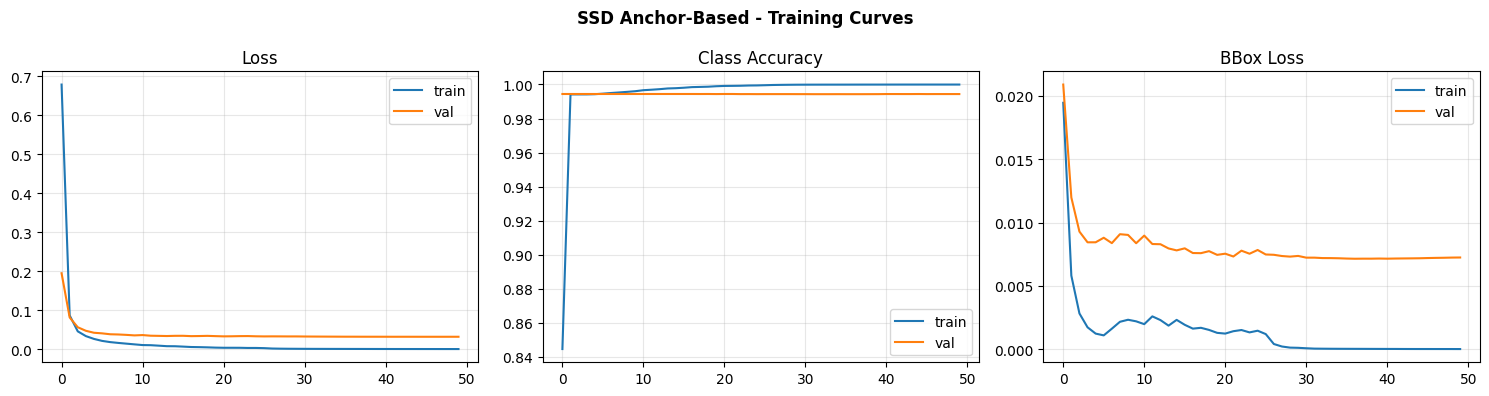

In [19]:
# Gráficos básicos de entrenamiento
def plot_history(history_df: pd.DataFrame, title: str = "SSD Anchor Training"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    # Loss total
    if 'loss' in history_df.columns:
        axes[0].plot(history_df['loss'], label='train')
    if 'val_loss' in history_df.columns:
        axes[0].plot(history_df['val_loss'], label='val')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Class accuracy
    acc_cols = [c for c in history_df.columns if 'class_out_accuracy' in c]
    if acc_cols:
        axes[1].plot(history_df[acc_cols[0]], label='train')
    if 'val_class_out_accuracy' in history_df.columns:
        axes[1].plot(history_df['val_class_out_accuracy'], label='val')
    axes[1].set_title('Class Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # BBox loss (si existe)
    bbox_cols = [c for c in history_df.columns if 'bbox_out' in c and 'loss' in c]
    if bbox_cols:
        axes[2].plot(history_df[bbox_cols[0]], label='train')
    val_bbox_cols = [c for c in history_df.columns if c.startswith('val_') and 'bbox_out' in c and 'loss' in c]
    if val_bbox_cols:
        axes[2].plot(history_df[val_bbox_cols[0]], label='val')
    axes[2].set_title('BBox Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(hist_df, title="SSD Anchor-Based - Training Curves")

### Paso 3.1a Evaluación en test


Métricas en el conjunto de test usando el modelo SSD entrenado.

⚠️ Nota Importante sobre Correcciones de Métricas

Se corrigieron los siguientes problemas que causaban métricas en cero:

1. **Mapeo de `category_id` COCO**: El archivo test_final.json usa category_ids `{2, 5, 6, 7}` pero el loader asumía `{1, 2, 3, 4}`. Ahora se auto-detecta desde el archivo COCO.

2. **Formato de BBox SSD**: El modelo SSD predice en formato `(xc, yc, w, h)` normalizado (centro), pero la inferencia lo trataba como esquina. Ahora se convierte correctamente.


In [8]:
# 🔄 Re-importar módulos corregidos y reconfigurar test_loader
import importlib
import utils_test_loader as _test_loader
import utils_ssd_infer as _ssd_infer

importlib.reload(_test_loader)
importlib.reload(_ssd_infer)

from utils_test_loader import COCOTargets
from utils_ssd_infer import run_ssd_inference

# Mapeo correcto de category_id según test_final.json
# Categories: {2: "door", 5: "footpath", 6: "obstacle", 7: "person"}
COCO_CAT_MAP = {2: 0, 5: 1, 6: 2, 7: 3}  # category_id -> class_index

TEST_IMG_SIZE=224

# Crear test_loader con mapeo correcto
test_loader = COCOTargets(
    coco_json_path=config.test_json,
    images_dir=config.test_img_dir,
    class_names=CLASS_NAMES,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    category_id_map=COCO_CAT_MAP,  # Usar mapeo explícito
)

print(f"✅ Test loader reconfigurado")
print(f"   Imágenes: {len(test_loader.images)}")
total_annots = sum(len(v) for v in test_loader.targets.values())
print(f"   Anotaciones cargadas: {total_annots}")
print(f"   Mapeo category_id: {test_loader.category_id_to_class}")

Loaded 84 images and 215 annotations.
✅ Test loader reconfigurado
   Imágenes: 84
   Anotaciones cargadas: 215
   Mapeo category_id: {2: 0, 5: 1, 6: 2, 7: 3}


In [46]:
# Evaluación SSD en test (usando test_loader reconfigurado de celda anterior)
from utils_eval import evaluate_model
import numpy as np

ssd_results = []
for images, gts, ids in test_loader.iter_batches(batch_size=8):
    images = images.astype(np.float32) / 255.0
    batch_results = run_ssd_inference(
        model=ssd_anchor_model,
        image_batch=images,
        class_names=CLASS_NAMES,
        image_ids=ids, # type: ignore
        ground_truths=gts,  # type: ignore
        model_name=SSD_MODEL_NAME,
        conf_threshold=0.25,  # Umbral reducido para capturar más predicciones
        nms_iou=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        # El modelo SSD predice (xc, yc, w, h) normalizado - formato centro
        # Nota: decode_ssd_predictions ahora convierte correctamente de centro a esquina
    )
    ssd_results.extend(batch_results)

ssd_metrics = evaluate_model(SSD_MODEL_NAME, ssd_results, CLASS_NAMES)
print("\n📊 SSD Test Metrics (corregido)")
print(f"mAP@50: {ssd_metrics.map_50:.4f}")
print(f"Precision: {ssd_metrics.precision:.4f} | Recall: {ssd_metrics.recall:.4f} | F1: {ssd_metrics.f1_score:.4f}")
print(f"Detection Acc: {ssd_metrics.detection_accuracy:.4f} | Avg IoU: {ssd_metrics.avg_iou:.4f}")
print(f"Avg Inference Time (ms/img): {ssd_metrics.inference_time_ms:.2f}")
print(f"\n📊 Totales: TP={ssd_metrics.total_tp}, FP={ssd_metrics.total_fp}, FN={ssd_metrics.total_fn}")
print(f"📊 Per-class AP: {ssd_metrics.per_class_ap}")


📊 SSD Test Metrics (corregido)
mAP@50: 0.0568
Precision: 0.5500 | Recall: 0.0512 | F1: 0.0936
Detection Acc: 0.1310 | Avg IoU: 0.6643
Avg Inference Time (ms/img): 44.01

📊 Totales: TP=11, FP=9, FN=204
📊 Per-class AP: {'door': 0.0, 'footpath': 0.13636363636363635, 'obstacle': 0.09090909090909091, 'person': 0.0}


### Paso 3.2a Visualizador de detecciones 

Predicciones totales en muestras: 29


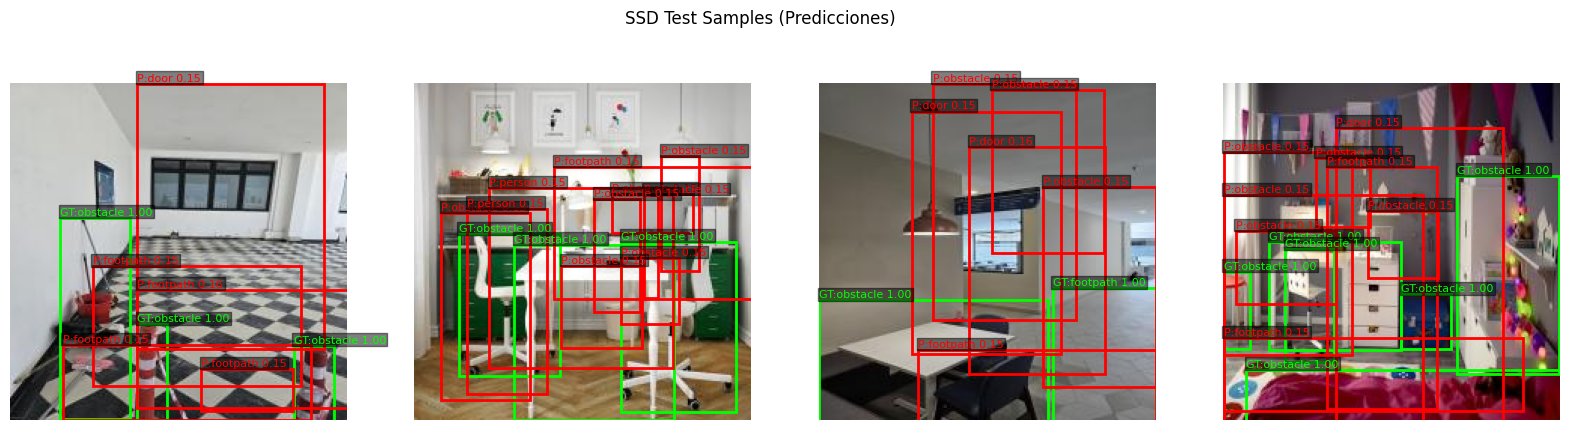

In [76]:
# Visualizar detecciones SSD en algunas imágenes
import importlib
import utils_ssd_infer as _ssd_infer
from utils_viz import show_random_samples

importlib.reload(_ssd_infer)
from utils_ssd_infer import run_ssd_inference

sample_images = []
sample_gts = []
sample_preds = []
total_preds = 0
for images, gts, ids in test_loader.iter_batches(batch_size=4):
    images_norm = images.astype(np.float32) / 255.0
    batch_results = run_ssd_inference(
        model=ssd_anchor_model, 
        image_batch=images_norm,
        class_names=CLASS_NAMES,
        image_ids=ids,  # type: ignore
        ground_truths=gts,  # type: ignore
        model_name=SSD_MODEL_NAME,
        conf_threshold=0.3,
        nms_iou=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        top_k=10,
    )
    for i in range(len(images)): # type: ignore
        sample_images.append(images[i]) # type: ignore
        sample_gts.append(gts[i]) # type: ignore
        sample_preds.append(batch_results[i].predictions)
        total_preds += len(batch_results[i].predictions)
    if len(sample_images) >= 4:
        break

print(f"Predicciones totales en muestras: {total_preds}")
if total_preds == 0:
    print("⚠️ No se encontraron predicciones. Prueba a reducir el umbral o revisar el modelo.")

show_random_samples(sample_images, sample_gts, sample_preds, max_samples=4, title="SSD Test Samples (Predicciones)")

## Paso 3b — Entrenamiento SSD Anchor V2 (Mejorado)

Entrenamos una versión mejorada del SSD con:
- **Focal Loss** para manejar el desbalance positivo/negativo
- **Hard Negative Mining** integrado en la loss
- **Multi-matching mejorado** con umbral IoU más bajo (0.35)
- **Center-based matching** para más muestras positivas
- **Data augmentation**: flip horizontal, jitter de color

In [59]:
# 🔄 Recarga de módulos actualizados para SSD V2
import importlib
import utils_ssd_model as _ssd_model
import utils_ssd_data as _ssd_data
import utils_ssd_losses as _ssd_losses

importlib.reload(_ssd_model)
importlib.reload(_ssd_data)
importlib.reload(_ssd_losses)

from utils_ssd_model import build_mobilenet_ssd_anchor_head
from utils_ssd_losses import (
    focal_loss_with_hard_negative_mining,
    ssd_multitask_loss,
    masked_bbox_smooth_l1_loss,
)
from utils_ssd_data import SSDAnchorDataGeneratorV2

# Configuración V2
SSD_MODEL_NAME_V2 = "ssd_anchor_v2"
SSD_V2_EPOCHS = 80  # Más épocas para aprender mejor

# Crear modelo desde cero (nuevos pesos)
ssd_anchor_model_v2 = build_mobilenet_ssd_anchor_head(
    input_shape=(BASELINE_CONFIG["ssd_v6"]["input_size"],) * 2 + (3,),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=BASELINE_CONFIG["ssd_v6"]["alpha"],
    feature_channels=256,
    use_batchnorm=True,
    model_name="MobileNetV2_SSD_Anchors_V2",
)

# Focal Loss con Hard Negative Mining para clasificación
focal_cls_loss = focal_loss_with_hard_negative_mining(
    alpha=0.25,      # Peso para clase minoritaria (objetos)
    gamma=2.0,       # Enfoque en ejemplos difíciles
    neg_pos_ratio=3.0  # 3 negativos por cada positivo
)

ssd_anchor_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
    loss={
        "class_out": focal_cls_loss,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={"class_out": 1.5, "bbox_out_sigmoid": 1.0},  # Más peso a clasificación
    metrics={"class_out": "accuracy"},
)

# Generadores V2 con mejor encoding y augmentation
train_gen_ssd_v2 = SSDAnchorDataGeneratorV2(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.35,         # Más bajo = más positivos
    use_center_matching=True,   # Matching por cercanía al centro
    center_radius=1.5,
    augment=True,               # Data augmentation activo
    shuffle=True,
)

val_gen_ssd_v2 = SSDAnchorDataGeneratorV2(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.35,
    use_center_matching=True,
    center_radius=1.5,
    augment=False,              # Sin augmentation en validación
    shuffle=False,
)

# Verificar proporción de positivos vs negativos en un batch
x_test, y_test = train_gen_ssd_v2[0]
bg_count = (y_test["class_out"][:, :, 0] == 1.0).sum()
fg_count = (y_test["class_out"][:, :, 0] == 0.0).sum()
total = bg_count + fg_count
print(f"✅ Balance en batch: {fg_count} positivos ({100*fg_count/total:.1f}%) vs {bg_count} negativos ({100*bg_count/total:.1f}%)")
print(f"   (V1 tenía ~0.3% positivos, V2 debería tener más)")
print(f"✅ Modelo V2 listo con Focal Loss + HNM")

✅ Balance en batch: 6078 positivos (21.5%) vs 22146 negativos (78.5%)
   (V1 tenía ~0.3% positivos, V2 debería tener más)
✅ Modelo V2 listo con Focal Loss + HNM


In [60]:
# Entrenamiento SSD Anchor V2
from utils_training import create_callbacks
import pandas as pd

ssd_v2_callbacks = create_callbacks(
    model_name=SSD_MODEL_NAME_V2,
    logs_dir=config.dirs["logs"],
    checkpoints_dir=config.dirs["models_chk"],
    monitor="val_loss",
    mode="min",
    patience_early=12,   # Más paciencia porque Focal Loss converge más lento
    patience_lr=6,
)

print("\n--- ENTRENANDO SSD ANCHOR V2 (FOCAL LOSS + HNM) ---")
print(f"   Épocas: {SSD_V2_EPOCHS}")
print(f"   IoU threshold: 0.35 (vs 0.5 en V1)")
print(f"   Focal Loss: alpha=0.25, gamma=2.0")
print(f"   Hard Negative Mining: ratio 3:1\n")

history_ssd_v2 = ssd_anchor_model_v2.fit(
    train_gen_ssd_v2,
    validation_data=val_gen_ssd_v2,
    epochs=SSD_V2_EPOCHS,
    callbacks=ssd_v2_callbacks,
    verbose=1,
)

# Guardar modelo final
final_path_v2 = os.path.join(config.dirs["models_final"], f"{SSD_MODEL_NAME_V2}.keras")
ssd_anchor_model_v2.save(final_path_v2)
print(f"✅ Modelo SSD V2 guardado en: {final_path_v2}")

# Guardar historial en CSV
hist_df_v2 = pd.DataFrame(history_ssd_v2.history)
hist_path_v2 = os.path.join(config.dirs["logs"], f"{SSD_MODEL_NAME_V2}_history.csv")
hist_df_v2.to_csv(hist_path_v2, index=False)
print(f"✅ Historial guardado en: {hist_path_v2}")

✅ Callbacks configurados para 'ssd_anchor_v2'

--- ENTRENANDO SSD ANCHOR V2 (FOCAL LOSS + HNM) ---
   Épocas: 80
   IoU threshold: 0.35 (vs 0.5 en V1)
   Focal Loss: alpha=0.25, gamma=2.0
   Hard Negative Mining: ratio 3:1

Epoch 1/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - bbox_out_sigmoid_loss: 0.0411 - class_out_accuracy: 0.4657 - class_out_loss: 0.9873 - loss: 1.5238
Epoch 1: val_loss improved from None to 0.73937, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v2_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 331s 7s/step - bbox_out_sigmoid_loss: 0.0342 - class_out_accuracy: 0.6553 - class_out_loss: 0.6571 - loss: 1.0208 - val_bbox_out_sigmoid_loss: 0.0384 - val_class_out_accuracy: 0.8086 - val_class_out_loss: 0.4758 - val_loss: 0.7394 - learning_rate: 3.0000e-04
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - bbox_out_sigmoid_loss: 0.0226 - class_out_accuracy: 0.8781 - class_out_loss: 0.2042 - loss: 0.3290
Epoch 2: val_loss improved from 0.

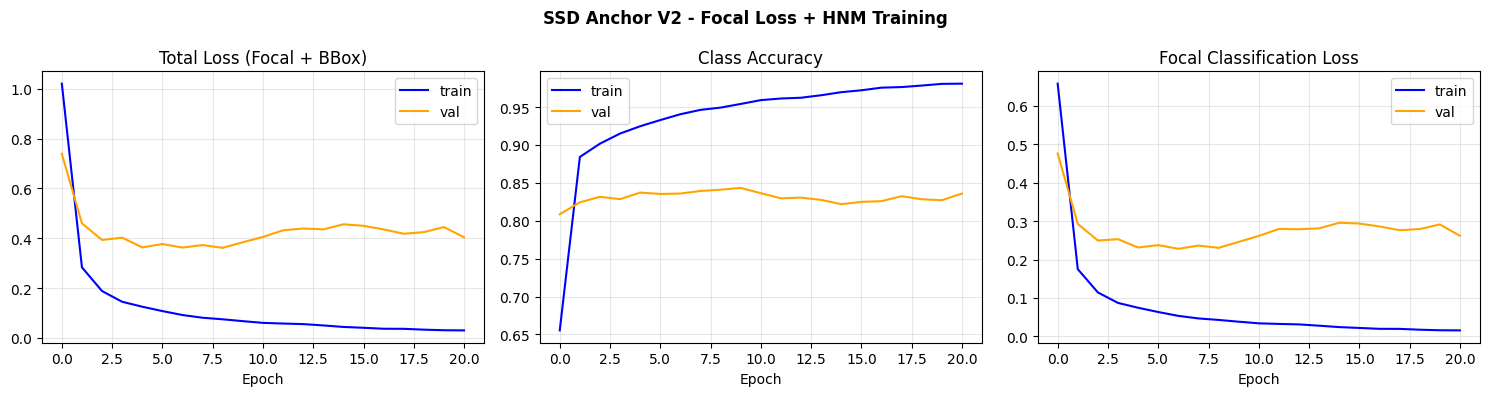

In [61]:
# Visualizar curvas de entrenamiento V2 (función modularizada en utils_viz)
import importlib
import utils_viz as _viz

importlib.reload(_viz)
from utils_viz import plot_ssd_v2_history

plot_ssd_v2_history(hist_df_v2, title="SSD Anchor V2 - Focal Loss + HNM Training")

### Paso 3.1b Evaluación en test 

In [63]:
# Evaluación en test set - SSD V2
import importlib
import utils_ssd_infer as _ssd_infer

importlib.reload(_ssd_infer)
from utils_ssd_infer import run_ssd_inference
from utils_eval import evaluate_model

# Predicciones con el modelo V2
ssd_v2_results = []
for images, gts, ids in test_loader.iter_batches(batch_size=8):
    images_norm = images.astype(np.float32) / 255.0
    batch_results = run_ssd_inference(
        model=ssd_anchor_model_v2,
        image_batch=images_norm,
        class_names=CLASS_NAMES,
        image_ids=ids,  # type: ignore
        ground_truths=gts,  # type: ignore
        model_name=SSD_MODEL_NAME_V2,
        conf_threshold=0.25,  # Umbral reducido para capturar más predicciones
        nms_iou=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    )
    ssd_v2_results.extend(batch_results)

print(f"📊 Total predicciones SSD V2: {sum(len(r.predictions) for r in ssd_v2_results)}")

# Evaluar métricas
ssd_v2_metrics = evaluate_model(SSD_MODEL_NAME_V2, ssd_v2_results, CLASS_NAMES)

print(f"\n=== Métricas SSD Anchor V2 (test) ===")
print(f"mAP@50:    {ssd_v2_metrics.map_50:.4f}")
print(f"Precision: {ssd_v2_metrics.precision:.4f}")
print(f"Recall:    {ssd_v2_metrics.recall:.4f}")
print(f"F1-Score:  {ssd_v2_metrics.f1_score:.4f}")
print(f"TP: {ssd_v2_metrics.total_tp}, FP: {ssd_v2_metrics.total_fp}, FN: {ssd_v2_metrics.total_fn}")

# Comparación V1 vs V2
print(f"\n📈 Comparación V1 vs V2:")
print(f"   V1 mAP: {ssd_metrics.map_50:.4f} → V2 mAP: {ssd_v2_metrics.map_50:.4f} ({'+' if ssd_v2_metrics.map_50 > ssd_metrics.map_50 else ''}{(ssd_v2_metrics.map_50 - ssd_metrics.map_50)*100:.1f}%)")
print(f"   V1 Recall: {ssd_metrics.recall:.4f} → V2 Recall: {ssd_v2_metrics.recall:.4f}")

📊 Total predicciones SSD V2: 1884

=== Métricas SSD Anchor V2 (test) ===
mAP@50:    0.1304
Precision: 0.0430
Recall:    0.3767
F1-Score:  0.0772
TP: 81, FP: 1803, FN: 134

📈 Comparación V1 vs V2:
   V1 mAP: 0.0568 → V2 mAP: 0.1304 (+7.4%)
   V1 Recall: 0.0512 → V2 Recall: 0.3767


### Paso 3.2b Visualizacion de detecciones

Predicciones totales en muestras: 13


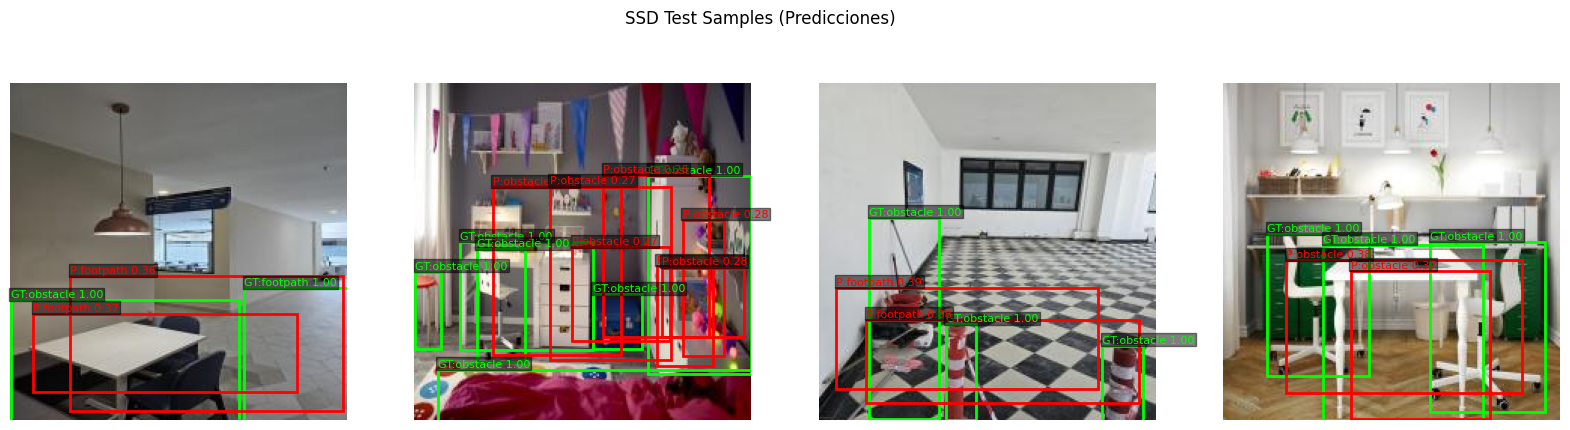

In [65]:
# Visualizar detecciones SSD en algunas imágenes
import importlib
import utils_ssd_infer as _ssd_infer
from utils_viz import show_random_samples

importlib.reload(_ssd_infer)
from utils_ssd_infer import run_ssd_inference

sample_images = []
sample_gts = []
sample_preds = []
total_preds = 0
for images, gts, ids in test_loader.iter_batches(batch_size=4):
    images_norm = images.astype(np.float32) / 255.0
    batch_results = run_ssd_inference(
        model=ssd_anchor_model_v2, 
        image_batch=images_norm,
        class_names=CLASS_NAMES,
        image_ids=ids,  # type: ignore
        ground_truths=gts,  # type: ignore
        model_name=SSD_MODEL_NAME,
        conf_threshold=0.3,
        nms_iou=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        top_k=10,
    )
    for i in range(len(images)): # type: ignore
        sample_images.append(images[i]) # type: ignore
        sample_gts.append(gts[i]) # type: ignore
        sample_preds.append(batch_results[i].predictions)
        total_preds += len(batch_results[i].predictions)
    if len(sample_images) >= 4:
        break

print(f"Predicciones totales en muestras: {total_preds}")
if total_preds == 0:
    print("⚠️ No se encontraron predicciones. Prueba a reducir el umbral o revisar el modelo.")

show_random_samples(sample_images, sample_gts, sample_preds, max_samples=4, title="SSD Test Samples (Predicciones)")

## Paso 4 — YOLOv11 (entrenamiento, métricas y gráficos)

Usamos la configuración base de `configuraciones.md` para reproducir YOLO V1 y guardar métricas/plots.

In [9]:
# Entrenamiento YOLOv11 V1 (baseline reproducible)
from utils_yolo_train import YoloTrainConfig, train_yolo
from utils_yolo_metrics import extract_yolo_metrics, plot_yolo_history
from utils_io import log
import os

yolo_cfg = BASELINE_CONFIG["yolo_v1"]
data_yaml = os.path.join(config.dirs["yolo_dataset"], "data.yaml")

train_cfg = YoloTrainConfig(
    model=yolo_cfg["model"],
    imgsz=yolo_cfg["imgsz"],
    epochs=yolo_cfg["epochs"],
    patience=15,
    batch=yolo_cfg["batch"],
    optimizer=yolo_cfg["optimizer"],
    lr0=yolo_cfg["lr0"],
    lrf=yolo_cfg["lrf"],
    cos_lr=True,
    warmup_epochs=yolo_cfg["warmup_epochs"],
    weight_decay=yolo_cfg["weight_decay"],
    mosaic=yolo_cfg["mosaic"],
    mixup=0.0,
    hsv_h=0.0,
    hsv_s=yolo_cfg["hsv_s"],
    hsv_v=yolo_cfg["hsv_v"],
    degrees=5.0,
    translate=0.05,
    scale=yolo_cfg["scale"],
    fliplr=yolo_cfg["fliplr"],
    project=config.dirs["logs"],
    name="yolo_v1",
    exist_ok=True,
    amp=True,
    plots=True,
    save=True,
    save_period=-1,
    val=True,
),
log("🚀 Iniciando entrenamiento YOLOv11 V1...")
_ = train_yolo(data_yaml=data_yaml, cfg=train_cfg) # type: ignore

🚀 Iniciando entrenamiento YOLOv11 V1...
⚠️ Error entrenando YOLO: 'tuple' object has no attribute 'model'


✅ Historial guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo_v1_history.csv
✅ Mejor modelo copiado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/../models/checkpoints/yolo_v1_best.pt (5.18 MB, int8~1.30 MB)


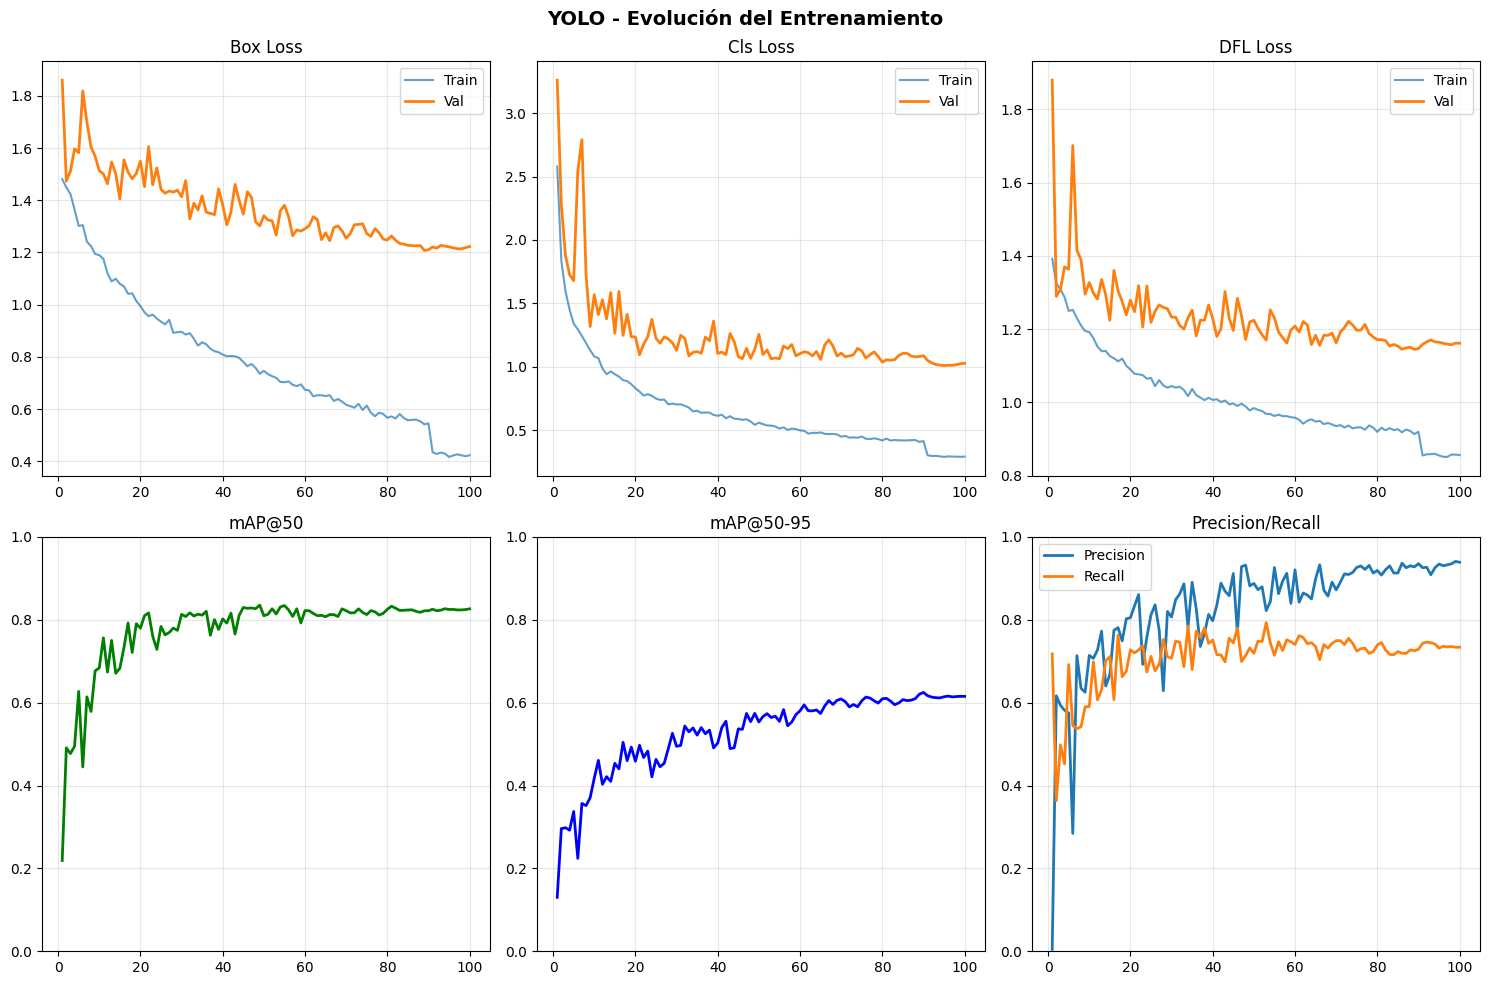

✅ Gráfico guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/yolo_v1_training.png


In [10]:
# Extracción de métricas y gráficos YOLO
yolo_results_dir = os.path.join(config.dirs["logs"], "yolo_v1")
yolo_hist_df = extract_yolo_metrics(yolo_results_dir, config.dirs["logs"], version_tag="yolo_v1")
if yolo_hist_df is not None:
    yolo_plot_path = os.path.join(config.dirs["visuals"], "yolo_v1_training.png")
    plot_yolo_history(yolo_hist_df, save_path=yolo_plot_path)

## Paso 4.1 — Evaluación en test (YOLOv11)

Evaluamos el modelo YOLO en el conjunto de test y calculamos métricas.

In [11]:
# Evaluación YOLO en test (usando test_loader reconfigurado con mapeo correcto)
import importlib
import utils_yolo_infer as _yolo_infer
from utils_eval import evaluate_model

importlib.reload(_yolo_infer)
from utils_yolo_infer import load_yolo_model, run_yolo_inference

yolo_best_path = os.path.join(config.dirs["models_chk"], "yolo_v1_best.pt")
if not os.path.exists(yolo_best_path):
    raise FileNotFoundError(f"No se encontró el modelo YOLO: {yolo_best_path}")

yolo_model = load_yolo_model(yolo_best_path)

yolo_results = []
for images, gts, ids in test_loader.iter_batches(batch_size=8):
    # YOLO espera imágenes en [0,255] uint8 o float, aquí usamos RGB ya resize
    batch_results = run_yolo_inference(
        model=yolo_model,
        image_batch=images, # type: ignore
        class_names=CLASS_NAMES,
        image_ids=ids, # type: ignore
        ground_truths=gts,  # type: ignore
        model_name="yolo_v1",
        conf_threshold=0.25,
        iou_threshold=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    )
    yolo_results.extend(batch_results)

yolo_metrics = evaluate_model("yolo_v1", yolo_results, CLASS_NAMES)
print("\n📊 YOLO Test Metrics (corregido)")
print(f"mAP@50: {yolo_metrics.map_50:.4f}")
print(f"Precision: {yolo_metrics.precision:.4f} | Recall: {yolo_metrics.recall:.4f} | F1: {yolo_metrics.f1_score:.4f}")
print(f"Detection Acc: {yolo_metrics.detection_accuracy:.4f} | Avg IoU: {yolo_metrics.avg_iou:.4f}")
print(f"Avg Inference Time (ms/img): {yolo_metrics.inference_time_ms:.2f}")
print(f"\n📊 Totales: TP={yolo_metrics.total_tp}, FP={yolo_metrics.total_fp}, FN={yolo_metrics.total_fn}")
print(f"📊 Per-class AP: {yolo_metrics.per_class_ap}")


📊 YOLO Test Metrics (corregido)
mAP@50: 0.4853
Precision: 0.6467 | Recall: 0.5023 | F1: 0.5654
Detection Acc: 0.8571 | Avg IoU: 0.7963
Avg Inference Time (ms/img): 9.57

📊 Totales: TP=108, FP=59, FN=107
📊 Per-class AP: {'door': 0.43929425837320574, 'footpath': 0.7840909090909091, 'obstacle': 0.2860713034176211, 'person': 0.4318181818181818}


## Paso 4.2 — Visualizador de muestras (YOLO)

Muestra detecciones YOLO en imágenes del test set.

Predicciones YOLO en muestras: 5


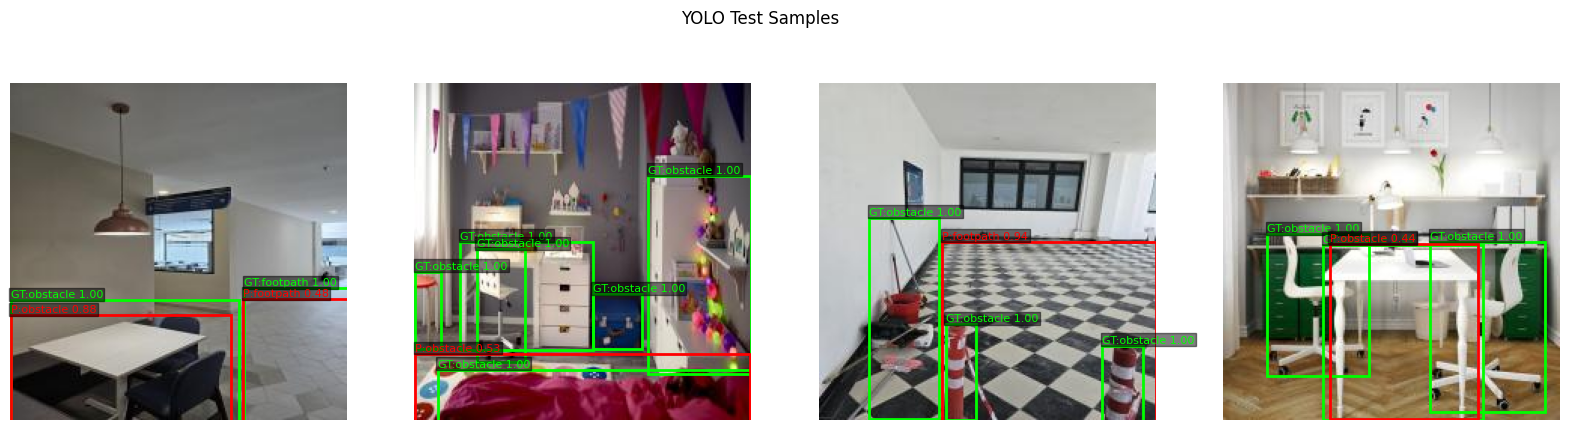

In [12]:
# Visualizar detecciones YOLO en algunas imágenes
import importlib
import utils_yolo_infer as _yolo_infer
from utils_viz import show_random_samples

importlib.reload(_yolo_infer)
from utils_yolo_infer import run_yolo_inference

yolo_sample_images = []
yolo_sample_gts = []
yolo_sample_preds = []
yolo_total_preds = 0
for images, gts, ids in test_loader.iter_batches(batch_size=4):
    batch_results = run_yolo_inference(
        model=yolo_model,
        image_batch=images, # type: ignore
        class_names=CLASS_NAMES,
        image_ids=ids, # type: ignore
        ground_truths=gts,  # type: ignore
        model_name="yolo_v1",
        conf_threshold=0.25,
        iou_threshold=0.50,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    )
    for i in range(len(images)): # type: ignore
        yolo_sample_images.append(images[i]) # type: ignore
        yolo_sample_gts.append(gts[i]) # type: ignore
        yolo_sample_preds.append(batch_results[i].predictions)
        yolo_total_preds += len(batch_results[i].predictions)
    if len(yolo_sample_images) >= 4:
        break

print(f"Predicciones YOLO en muestras: {yolo_total_preds}")
show_random_samples(yolo_sample_images, yolo_sample_gts, yolo_sample_preds, max_samples=4, title="YOLO Test Samples")

## Paso 5 — Comparativas avanzadas

Análisis comparativo avanzado entre SSD y YOLO: métricas globales, matriz de confusión, dispersión por tamaño y análisis de errores.

In [69]:
# Tabla comparativa de métricas globales
from utils_compare import build_comparison_table

compare_df = build_comparison_table(ssd_v2_metrics, yolo_metrics)
compare_df

,model,mAP@50,precision,recall,f1,det_acc,avg_iou,time_ms
0,SSD,0.130386,0.042994,0.376744,0.077180,0.809524,0.613018,393.362335
1,YOLO,0.485319,0.646707,0.502326,0.565445,0.857143,0.796324,9.028316


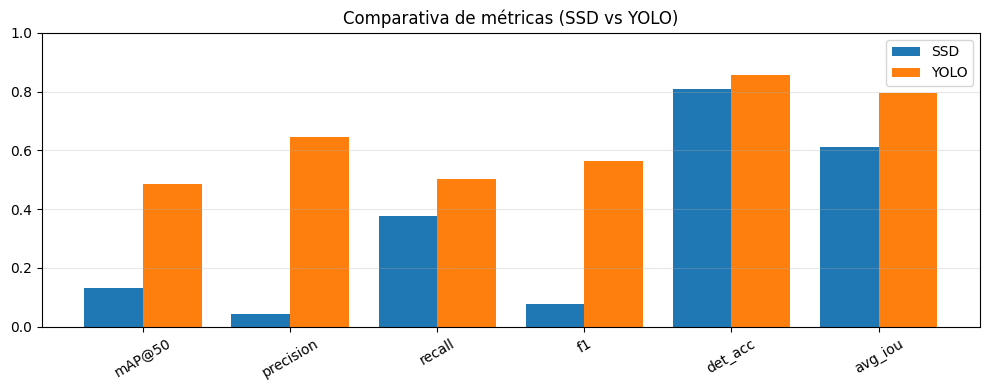

In [70]:
# Comparativa visual de métricas
from utils_compare import plot_metric_comparison

plot_metric_comparison(compare_df)

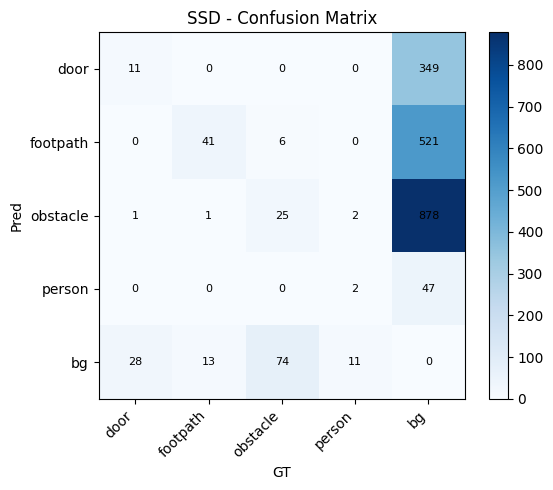

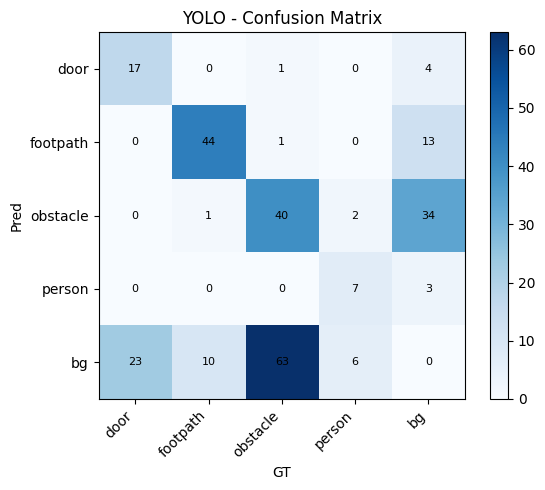

In [72]:
# Matrices de confusión
from utils_compare import plot_confusion_matrices

plot_confusion_matrices(ssd_v2_metrics, yolo_metrics, CLASS_NAMES)

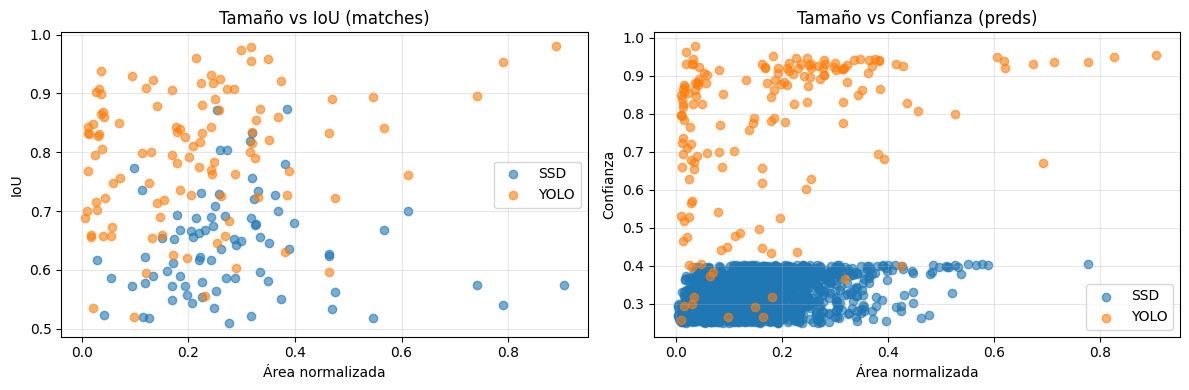

In [73]:
# Dispersión: tamaño vs IoU (matches) y tamaño vs confianza (preds)
from utils_compare import plot_size_scatter

plot_size_scatter(ssd_v2_results, yolo_results, (TEST_IMG_SIZE, TEST_IMG_SIZE))

SSD FP/FN: 5 5
YOLO FP/FN: 5 5

SSD - False Positives (mostrando 3)


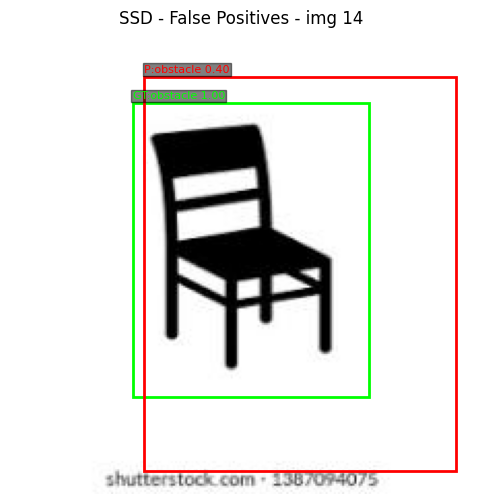

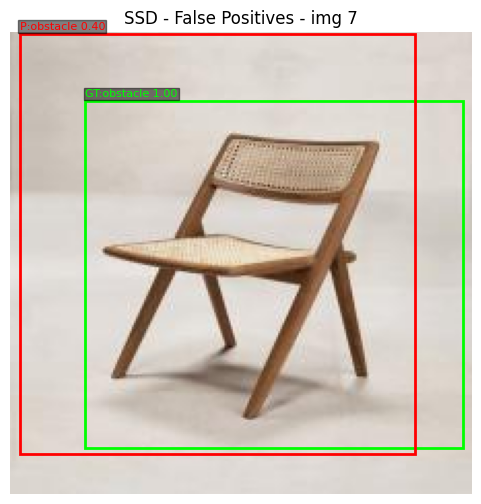

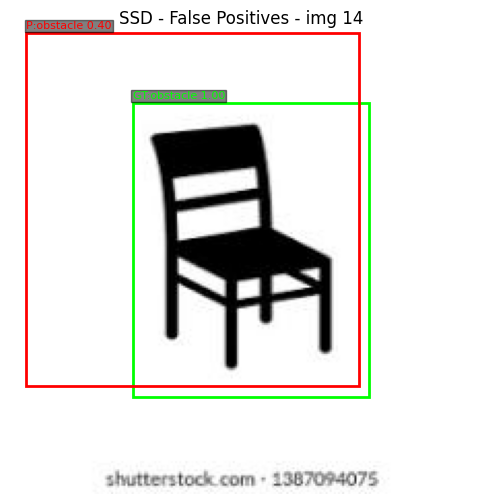


SSD - False Negatives (mostrando 3)


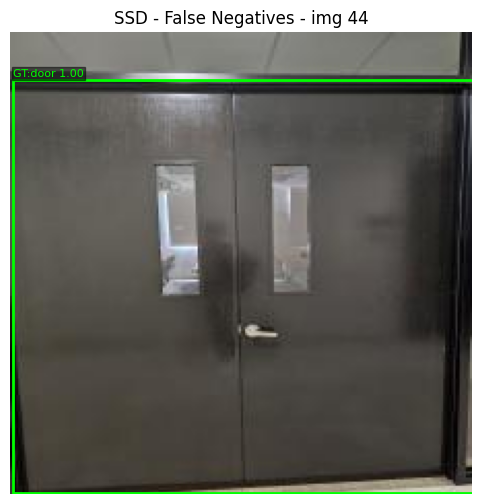

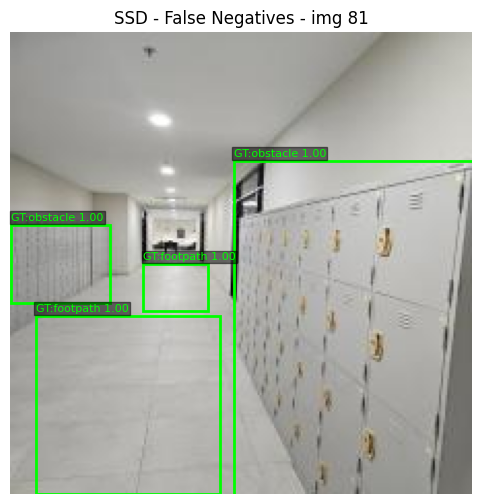

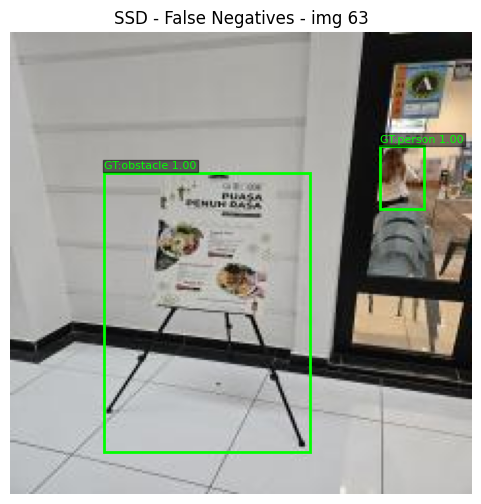


YOLO - False Positives (mostrando 3)


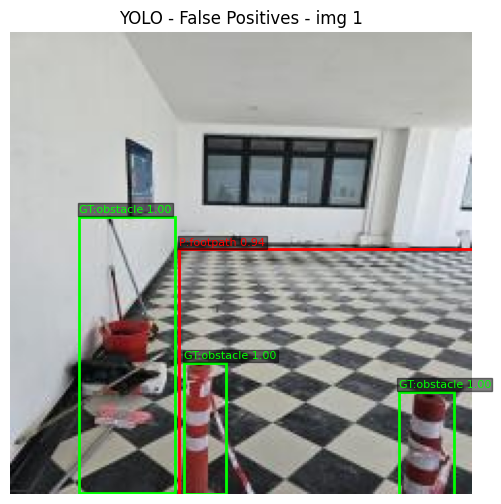

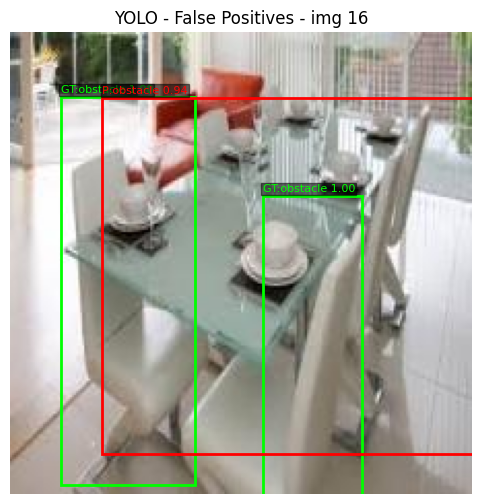

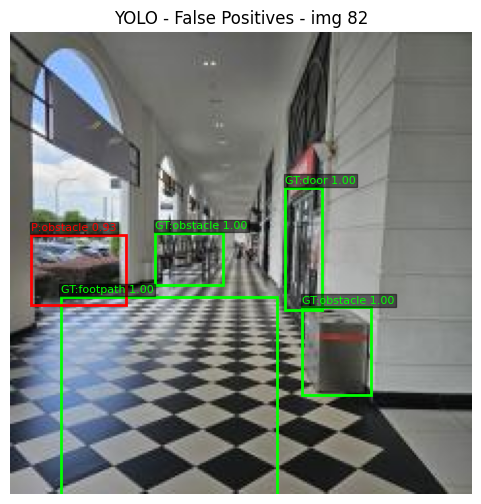


YOLO - False Negatives (mostrando 3)


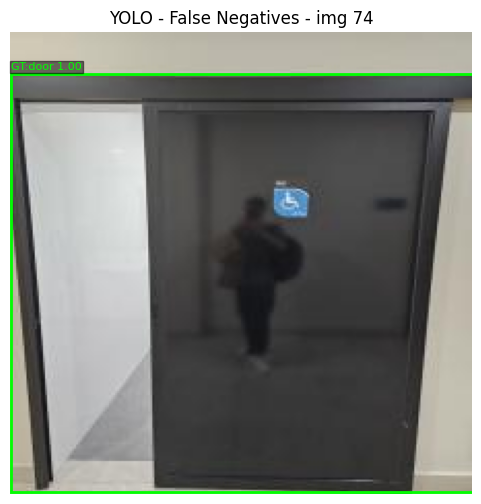

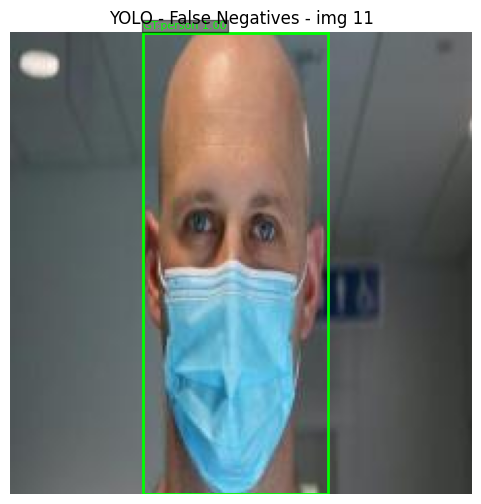

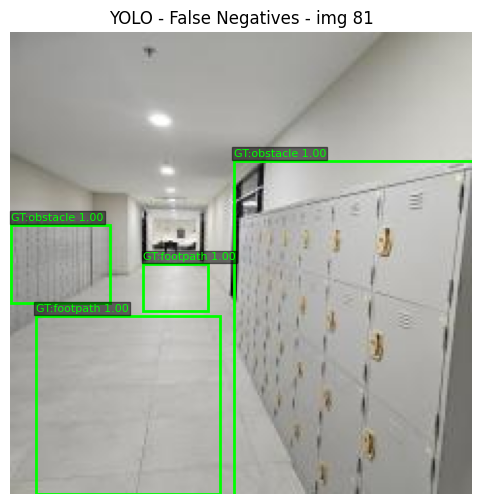

In [74]:
# Análisis de errores: FP/FN y visualización rápida
from utils_compare import run_error_analysis

run_error_analysis(
    ssd_results=ssd_v2_results,
    yolo_results=yolo_results,
    test_loader=test_loader,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    iou_threshold=0.5,
    top_k=5,
)

## Paso 6 — Matriz de evaluación final

Matriz final de decisión con dimensiones normalizadas (precisión, velocidad, robustez, complejidad) y score global.

Base de complejidad: time_ms


,model,precision_score,speed_score,robustness_score,complexity_score,overall_score
0,SSD,0.273528,0.0,0.809524,0.0,0.271316
1,YOLO,0.615696,1.0,0.857143,1.0,0.817707


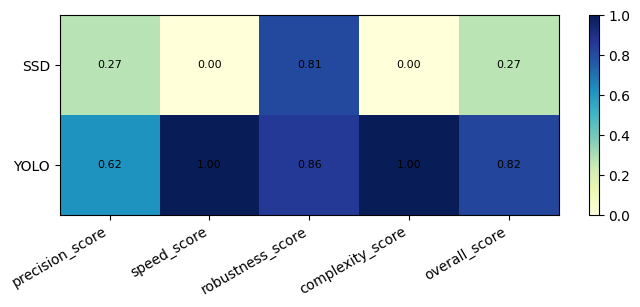

In [75]:
# Matriz final de evaluación
import importlib
import utils_compare
importlib.reload(utils_compare)
from utils_compare import build_final_evaluation_matrix, plot_final_matrix

final_df = build_final_evaluation_matrix(ssd_v2_metrics, yolo_metrics)
print("Base de complejidad:", final_df.attrs.get("complexity_basis"))
display(final_df)
plot_final_matrix(final_df)

## Paso 3c - Entrenamiento SSD Anchor V3 (Balanced Matching)

Mejoras sobre V2 para resolver el problema de **precisión baja** (muchos falsos positivos):

**Cambios en Data Generator (`SSDAnchorDataGeneratorV3`):**
- IoU threshold: 0.35 → **0.45** (anchors más selectivos)
- Center radius: 1.5 → **1.0** (matching menos agresivo)
- **Ignore zone**: anchors con IoU ∈ [0.30, 0.45) se ignoran en la loss
- Augmentation mejorada: blur gaussiano opcional

**Cambios en Inferencia:**
- Confidence threshold: 0.25 → **0.45** (menos predicciones ruidosas)
- NMS threshold: 0.50 → **0.30** (más supresión de boxes redundantes)

**Objetivo**: Mantener el recall ganado en V2 (~38%) pero mejorar precision (de 4% a >20%).

In [3]:
# 🔄 Re-importar módulos corregidos y reconfigurar test_loader
import importlib
import utils_test_loader as _test_loader
import utils_ssd_infer as _ssd_infer

importlib.reload(_test_loader)
importlib.reload(_ssd_infer)

from utils_test_loader import COCOTargets
from utils_ssd_infer import run_ssd_inference

# Mapeo correcto de category_id según test_final.json
# Categories: {2: "door", 5: "footpath", 6: "obstacle", 7: "person"}
COCO_CAT_MAP = {2: 0, 5: 1, 6: 2, 7: 3}  # category_id -> class_index

TEST_IMG_SIZE=224

# Crear test_loader con mapeo correcto
test_loader = COCOTargets(
    coco_json_path=config.test_json,
    images_dir=config.test_img_dir,
    class_names=CLASS_NAMES,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    category_id_map=COCO_CAT_MAP,  # Usar mapeo explícito
)

print(f"✅ Test loader reconfigurado")
print(f"   Imágenes: {len(test_loader.images)}")
total_annots = sum(len(v) for v in test_loader.targets.values())
print(f"   Anotaciones cargadas: {total_annots}")
print(f"   Mapeo category_id: {test_loader.category_id_to_class}")

Loaded 84 images and 215 annotations.
✅ Test loader reconfigurado
   Imágenes: 84
   Anotaciones cargadas: 215
   Mapeo category_id: {2: 0, 5: 1, 6: 2, 7: 3}


In [5]:
# Anchors y aspect ratios ajustados (vertical/horizontal)
from utils_ssd_anchors import compute_kmeans_anchors, derive_aspect_ratios, generate_anchors, log_anchor_summary
from utils_io import log

# Configuración base de anchors
FEATURE_MAP_SIZE = 7  # MobileNetV2 output para input 224 (aprox 7x7)
SCALES = [0.10, 0.20, 0.35]  # escalas base (ajustables)

# Intentar derivar aspect ratios desde K-Means (si scikit-learn está disponible)
try:
    kmeans_anchors = compute_kmeans_anchors(config.train_json, n_clusters=6)
    aspect_ratios = derive_aspect_ratios(kmeans_anchors)
    log(f"✅ Aspect ratios derivados por K-Means: {np.round(aspect_ratios, 2)}")
except Exception as exc:
    # Fallback: ratios manuales balanceados para vertical/horizontal
    aspect_ratios = [0.33, 0.50, 1.0, 2.0, 3.0]
    log(f"⚠️ K-Means no disponible: {exc}")
    log(f"   Usando aspect ratios manuales: {aspect_ratios}")

ANCHORS = generate_anchors(
    feature_map_size=FEATURE_MAP_SIZE,
    scales=SCALES,
    aspect_ratios=aspect_ratios,
)
log_anchor_summary(ANCHORS)

ANCHORS_PER_CELL = len(SCALES) * len(aspect_ratios)
log(f"🔧 Anchors por celda: {ANCHORS_PER_CELL}")
log(f"🔧 Total anchors: {ANCHORS.shape[0]}")

✅ Aspect ratios derivados por K-Means: [0.5  0.7  0.93 1.   1.47 3.02]
📦 Anchors: 882
   Area min/max: 0.0100 / 0.1225
   w min/max: 0.0710 / 0.6082
   h min/max: 0.0575 / 0.4933
🔧 Anchors por celda: 18
🔧 Total anchors: 882


✅ Balance V3: 2328 positivos (8.2%) vs 25896 negativos (91.8%)
   Anchors ignorados (sample_weight=0): 33 (0.1%)
   (V2 tenía ~21.5% positivos, V3 debería tener ~10-15%)
✅ Modelo V3 listo con matching conservador
✅ Callbacks configurados para 'ssd_anchor_v3'

--- ENTRENANDO SSD ANCHOR V3 (BALANCED MATCHING) ---
   Épocas: 80
   IoU threshold: 0.45 (vs 0.35 en V2)
   Center radius: 1.0 (vs 1.5 en V2)
   Ignore zone: IoU ∈ [0.30, 0.45)

Epoch 1/80


2026-02-02 22:45:00.055515: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_out_sigmoid_loss: 0.0396 - class_out_accuracy: 0.3633 - class_out_loss: 1.6734 - loss: 2.5515
Epoch 1: val_loss improved from None to 1.06353, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v3_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - bbox_out_sigmoid_loss: 0.0330 - class_out_accuracy: 0.5685 - class_out_loss: 1.1777 - loss: 1.7987 - val_bbox_out_sigmoid_loss: 0.0367 - val_class_out_accuracy: 0.8849 - val_class_out_loss: 0.6948 - val_loss: 1.0635 - learning_rate: 3.0000e-04
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - bbox_out_sigmoid_loss: 0.0216 - class_out_accuracy: 0.9199 - class_out_loss: 0.3540 - loss: 0.5524
Epoch 2: val_loss improved from 1.06353 to 0.55657, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v3_best.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - bbox_out_sigmoid_loss: 0.0206 - class_out_accuracy: 0.9235 - class_o

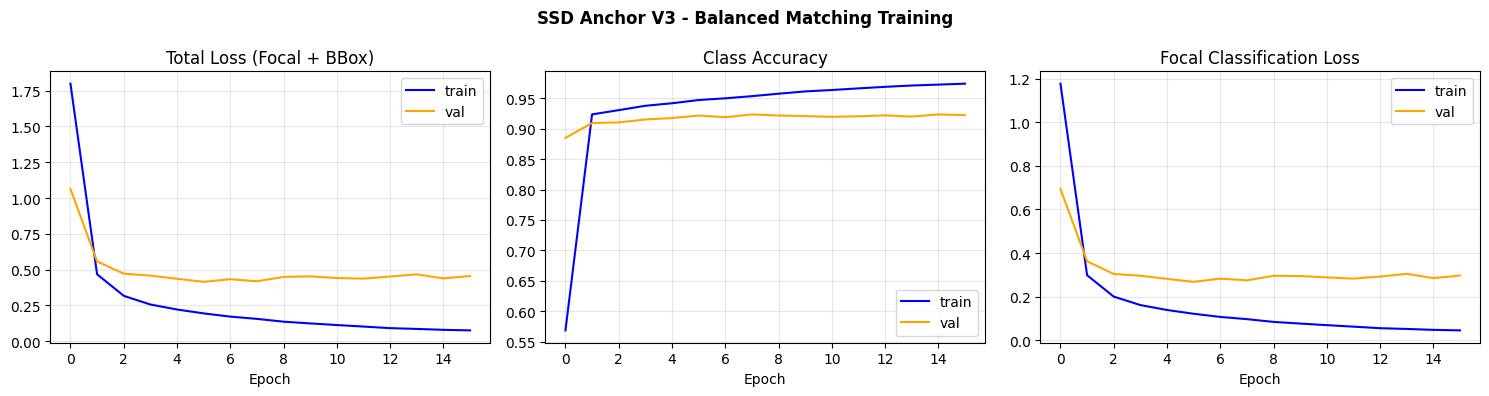

📊 Total predicciones SSD V3: 0

=== Métricas SSD Anchor V3 (test) ===
mAP@50:    0.0000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
TP: 0, FP: 0, FN: 215

📈 Comparación V1 → V2 → V3:


NameError: name 'ssd_metrics' is not defined

In [7]:
import importlib
import utils_ssd_model as _ssd_model
import utils_ssd_data as _ssd_data
import utils_ssd_losses as _ssd_losses
import tensorflow as tf

importlib.reload(_ssd_model)
importlib.reload(_ssd_data)
importlib.reload(_ssd_losses)

from utils_ssd_model import build_mobilenet_ssd_anchor_head
from utils_ssd_losses import (
    focal_loss_with_ignore_mask,
    masked_bbox_smooth_l1_loss,
)
from utils_ssd_data import SSDAnchorDataGeneratorV3

# Configuración V3
SSD_MODEL_NAME_V3 = "ssd_anchor_v3"
SSD_V3_EPOCHS = 80

# Crear modelo desde cero
ssd_anchor_model_v3 = build_mobilenet_ssd_anchor_head(
    input_shape=(BASELINE_CONFIG["ssd_v6"]["input_size"],) * 2 + (3,),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=BASELINE_CONFIG["ssd_v6"]["alpha"],
    feature_channels=256,
    use_batchnorm=True,
    model_name="MobileNetV2_SSD_Anchors_V3",
)

# Focal Loss con HNM
focal_cls_loss_v3 = focal_loss_with_ignore_mask(
    alpha=0.25,
    gamma=2.0,
    neg_pos_ratio=3.0,
)

ssd_anchor_model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
    loss={
        "class_out": focal_cls_loss_v3,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={"class_out": 1.5, "bbox_out_sigmoid": 1.0},
    metrics={"class_out": "accuracy"},
)

# Generadores V3 con matching conservador
train_gen_ssd_v3 = SSDAnchorDataGeneratorV3(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.45,
    iou_ignore_threshold=0.30,
    use_center_matching=True,
    center_radius=1.0,
    augment=True,
    shuffle=True,
)

val_gen_ssd_v3 = SSDAnchorDataGeneratorV3(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=BASELINE_CONFIG["ssd_v6"]["batch"],
    img_size=BASELINE_CONFIG["ssd_v6"]["input_size"],
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.45,
    iou_ignore_threshold=0.30,
    use_center_matching=True,
    center_radius=1.0,
    augment=False,
    shuffle=False,
)

# Verificar proporción de positivos (V3 retorna (x, y, sample_weight))
x_test, y_test, sw_test = train_gen_ssd_v3[0]
bg_count = (y_test["class_out"][:, :, 0] == 1.0).sum()
fg_count = (y_test["class_out"][:, :, 0] == 0.0).sum()
ignore_count = (sw_test["class_out"] == 0.0).sum()
total = bg_count + fg_count
print(f"✅ Balance V3: {fg_count} positivos ({100*fg_count/total:.1f}%) vs {bg_count} negativos ({100*bg_count/total:.1f}%)")
print(f"   Anchors ignorados (sample_weight=0): {ignore_count} ({100*ignore_count/(total):.1f}%)")
print(f"   (V2 tenía ~21.5% positivos, V3 debería tener ~10-15%)")
print(f"✅ Modelo V3 listo con matching conservador")

from utils_training import create_callbacks
import pandas as pd

ssd_v3_callbacks = create_callbacks(
    model_name=SSD_MODEL_NAME_V3,
    logs_dir=config.dirs["logs"],
    checkpoints_dir=config.dirs["models_chk"],
    monitor="val_loss",
    mode="min",
    patience_early=10,
    patience_lr=5,
)

print("\n--- ENTRENANDO SSD ANCHOR V3 (BALANCED MATCHING) ---")
print(f"   Épocas: {SSD_V3_EPOCHS}")
print(f"   IoU threshold: 0.45 (vs 0.35 en V2)")
print(f"   Center radius: 1.0 (vs 1.5 en V2)")
print(f"   Ignore zone: IoU ∈ [0.30, 0.45)\n")

history_ssd_v3 = ssd_anchor_model_v3.fit(
    train_gen_ssd_v3,
    validation_data=val_gen_ssd_v3,
    epochs=SSD_V3_EPOCHS,
    callbacks=ssd_v3_callbacks,
    verbose=1,
)

# Guardar modelo final
final_path_v3 = os.path.join(config.dirs["models_final"], f"{SSD_MODEL_NAME_V3}.keras")
ssd_anchor_model_v3.save(final_path_v3)
print(f"✅ Modelo SSD V3 guardado en: {final_path_v3}")

# Guardar historial en CSV
hist_df_v3 = pd.DataFrame(history_ssd_v3.history)
hist_path_v3 = os.path.join(config.dirs["logs"], f"{SSD_MODEL_NAME_V3}_history.csv")
hist_df_v3.to_csv(hist_path_v3, index=False)
print(f"✅ Historial guardado en: {hist_path_v3}")


# Visualizar curvas de entrenamiento V3
from utils_viz import plot_ssd_v2_history

plot_ssd_v2_history(hist_df_v3, title="SSD Anchor V3 - Balanced Matching Training")




In [2]:
# ============================================================================
# EVALUACIÓN SSD V3 - Celda independiente (carga modelo desde disco)
# ============================================================================

# --- 1. Imports y configuración base ---
from __future__ import annotations
import os
import sys
import importlib
import numpy as np

PROJECT_ROOT = "/Users/admin/Documents/TFM_UNIR"
SRC_PATH = os.path.join(PROJECT_ROOT, "02_ING_MODELOS", "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Recargar módulos para asegurar última versión
import utils_config as _config
import utils_test_loader as _test_loader
import utils_ssd_infer as _ssd_infer
import utils_eval as _eval

importlib.reload(_config)
importlib.reload(_test_loader)
importlib.reload(_ssd_infer)
importlib.reload(_eval)

from utils_config import ProjectConfig
from utils_test_loader import COCOTargets
from utils_ssd_infer import run_ssd_inference, decode_ssd_predictions
from utils_eval import evaluate_model

import tensorflow as tf

# --- 2. Configuración y constantes ---
config = ProjectConfig(base_project_dir=PROJECT_ROOT)
CLASS_NAMES = ["door", "footpath", "obstacle", "person"]
COCO_CAT_MAP = {2: 0, 5: 1, 6: 2, 7: 3}
TEST_IMG_SIZE = 224
SSD_MODEL_NAME_V3 = "ssd_anchor_v3"

# --- 3. Cargar modelo desde disco ---
model_path = os.path.join(config.dirs["models_final"], f"{SSD_MODEL_NAME_V3}.keras")
print(f"📂 Cargando modelo desde: {model_path}")

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Modelo no encontrado: {model_path}")

ssd_anchor_model_v3 = tf.keras.models.load_model(model_path, compile=False)
print(f"✅ Modelo cargado: {ssd_anchor_model_v3.name}")

# --- 4. Cargar test loader ---
test_loader = COCOTargets(
    coco_json_path=config.test_json,
    images_dir=config.test_img_dir,
    class_names=CLASS_NAMES,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    category_id_map=COCO_CAT_MAP,
)
print(f"✅ Test loader: {len(test_loader.images)} imágenes, {sum(len(v) for v in test_loader.targets.values())} anotaciones")

# --- 5. Diagnóstico rápido de confianzas ---
print("\n🔍 Diagnóstico de distribución de confianzas...")
sample_images, _, _ = next(iter(test_loader.iter_batches(batch_size=16)))
sample_images_norm = sample_images.astype(np.float32) / 255.0

outputs = ssd_anchor_model_v3.predict(sample_images_norm, verbose=0)
class_logits = outputs["class_out"]
class_probs = tf.nn.softmax(class_logits, axis=-1).numpy()
non_bg_probs = class_probs[:, :, 1:]
max_conf = np.max(non_bg_probs, axis=-1)

print(f"   Confianza máxima: {max_conf.max():.4f}")
print(f"   Percentil 99: {np.percentile(max_conf, 99):.4f}")
print(f"   Percentil 95: {np.percentile(max_conf, 95):.4f}")

# --- 6. Búsqueda del umbral óptimo ---
print("\n🎯 Buscando umbral óptimo (maximizar F1)...")

best_f1 = 0
best_thresh = 0.10
results_by_thresh = {}

for conf_thresh in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    results = []
    for images, gts, ids in test_loader.iter_batches(batch_size=8):
        images_norm = images.astype(np.float32) / 255.0
        batch_results = run_ssd_inference(
            model=ssd_anchor_model_v3,
            image_batch=images_norm,
            class_names=CLASS_NAMES,
            image_ids=ids,  # type: ignore
            ground_truths=gts,  # type: ignore
            model_name=SSD_MODEL_NAME_V3,
            conf_threshold=conf_thresh,
            nms_iou=0.40,
            image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        )
        results.extend(batch_results)
    
    metrics = evaluate_model(SSD_MODEL_NAME_V3, results, CLASS_NAMES)
    results_by_thresh[conf_thresh] = (results, metrics)
    
    print(f"   thresh={conf_thresh:.2f}: P={metrics.precision:.3f}, R={metrics.recall:.3f}, F1={metrics.f1_score:.3f}, mAP={metrics.map_50:.3f}")
    
    if metrics.f1_score > best_f1:
        best_f1 = metrics.f1_score
        best_thresh = conf_thresh

print(f"\n✅ Umbral óptimo: {best_thresh} (F1={best_f1:.4f})")

# --- 7. Usar el umbral óptimo para métricas finales ---
ssd_v3_results, ssd_v3_metrics = results_by_thresh[best_thresh]
total_preds = sum(len(r.predictions) for r in ssd_v3_results)

print(f"\n{'='*50}")
print(f"=== Métricas SSD Anchor V3 (test) - Umbral {best_thresh} ===")
print(f"{'='*50}")
print(f"📊 Total predicciones: {total_preds}")
print(f"mAP@50:    {ssd_v3_metrics.map_50:.4f}")
print(f"Precision: {ssd_v3_metrics.precision:.4f}")
print(f"Recall:    {ssd_v3_metrics.recall:.4f}")
print(f"F1-Score:  {ssd_v3_metrics.f1_score:.4f}")
print(f"TP: {ssd_v3_metrics.total_tp}, FP: {ssd_v3_metrics.total_fp}, FN: {ssd_v3_metrics.total_fn}")
print(f"\n📊 Per-class AP: {ssd_v3_metrics.per_class_ap}")

# --- 8. Análisis del problema de confianzas bajas ---
print(f"\n⚠️ NOTA: El modelo SSD V3 tiene confianzas máximas bajas (~{max_conf.max():.2f})")
print("   Esto indica que el modelo no está seguro de sus predicciones.")
print("   Posibles causas:")
print("   1. Desbalance severo entre background y objetos durante entrenamiento")
print("   2. El softmax sobre muchos anchors diluye las probabilidades")
print("   3. El modelo necesita más épocas o ajuste de hiperparámetros")

📂 Cargando modelo desde: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/ssd_anchor_v3.keras
✅ Modelo cargado: MobileNetV2_SSD_Anchors_V3
Loaded 84 images and 215 annotations.
✅ Test loader: 84 imágenes, 215 anotaciones

🔍 Diagnóstico de distribución de confianzas...
   Confianza máxima: 0.3847
   Percentil 99: 0.3328
   Percentil 95: 0.2647

🎯 Buscando umbral óptimo (maximizar F1)...
   thresh=0.05: P=0.137, R=0.288, F1=0.186, mAP=0.167
   thresh=0.10: P=0.137, R=0.288, F1=0.186, mAP=0.167
   thresh=0.15: P=0.137, R=0.288, F1=0.186, mAP=0.167
   thresh=0.20: P=0.137, R=0.288, F1=0.186, mAP=0.167
   thresh=0.25: P=0.141, R=0.288, F1=0.190, mAP=0.167
   thresh=0.30: P=0.222, R=0.237, F1=0.229, mAP=0.146

✅ Umbral óptimo: 0.3 (F1=0.2292)

=== Métricas SSD Anchor V3 (test) - Umbral 0.3 ===
📊 Total predicciones: 230
mAP@50:    0.1455
Precision: 0.2217
Recall:    0.2372
F1-Score:  0.2292
TP: 51, FP: 179, FN: 164

📊 Per-class AP: {'door': 0.11363636363636363, 'footpath': 0

In [ ]:
# Comparación V1 vs V2 vs V3
print(f"\n📈 Comparación V1 → V2 → V3:")
print(f"   mAP:       V1={ssd_metrics.map_50:.3f} → V2={ssd_v2_metrics.map_50:.3f} → V3={ssd_v3_metrics.map_50:.3f}")
print(f"   Precision: V1={ssd_metrics.precision:.3f} → V2={ssd_v2_metrics.precision:.3f} → V3={ssd_v3_metrics.precision:.3f}")
print(f"   Recall:    V1={ssd_metrics.recall:.3f} → V2={ssd_v2_metrics.recall:.3f} → V3={ssd_v3_metrics.recall:.3f}")
print(f"   FP:        V1={ssd_metrics.total_fp} → V2={ssd_v2_metrics.total_fp} → V3={ssd_v3_metrics.total_fp}")


Predicciones totales V3 en muestras: 6


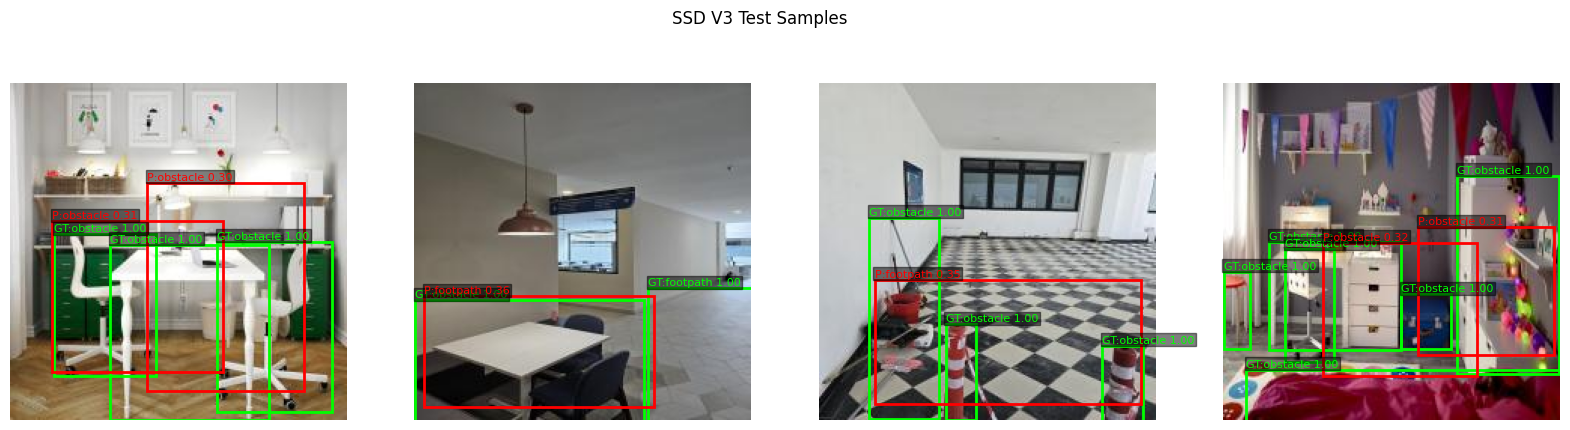

In [8]:
# Visualizar detecciones SSD V3
from utils_viz import show_random_samples

sample_images_v3 = []
sample_gts_v3 = []
sample_preds_v3 = []
total_preds_v3 = 0

for images, gts, ids in test_loader.iter_batches(batch_size=4):
    images_norm = images.astype(np.float32) / 255.0
    batch_results = run_ssd_inference(
        model=ssd_anchor_model_v3, 
        image_batch=images_norm,
        class_names=CLASS_NAMES,
        image_ids=ids,  # type: ignore
        ground_truths=gts,  # type: ignore
        model_name=SSD_MODEL_NAME_V3,
        conf_threshold=0.45,
        nms_iou=0.30,
        image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        top_k=10,
    )
    for i in range(len(images)):  # type: ignore
        sample_images_v3.append(images[i])  # type: ignore
        sample_gts_v3.append(gts[i])  # type: ignore
        sample_preds_v3.append(batch_results[i].predictions)
        total_preds_v3 += len(batch_results[i].predictions)
    if len(sample_images_v3) >= 4:
        break

print(f"Predicciones totales V3 en muestras: {total_preds_v3}")
show_random_samples(sample_images_v3, sample_gts_v3, sample_preds_v3, max_samples=4, title="SSD V3 Test Samples")

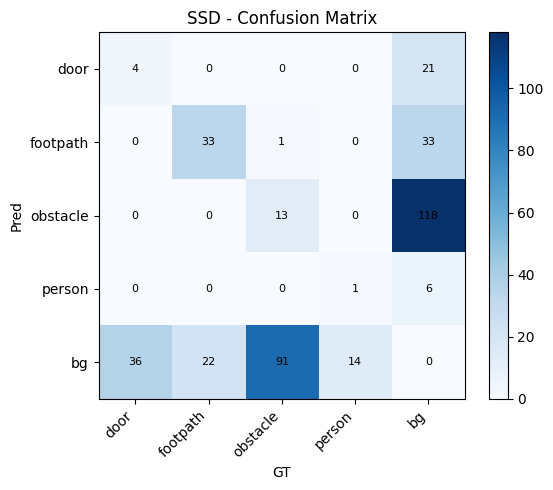

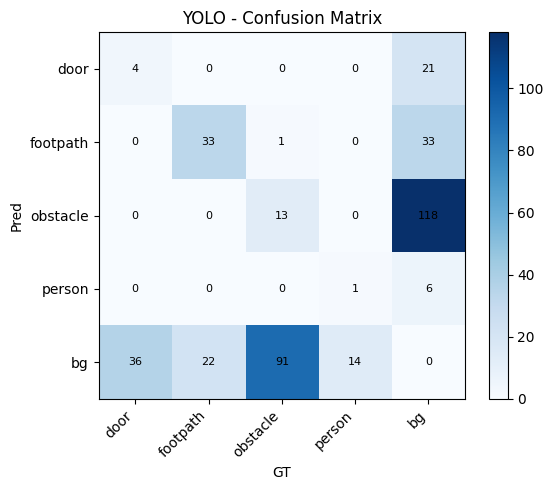

In [3]:
# Matrices de confusión
from utils_compare import plot_confusion_matrices

plot_confusion_matrices(ssd_v3_metrics, ssd_v3_metrics, CLASS_NAMES)

## Paso 3d - Entrenamiento SSD Anchor V4 (Sigmoid + Objectness)

**Mejoras sobre V3 para resolver el problema de confianzas bajas:**

### Problema identificado en V3:
- Confianza máxima ~0.38 (muy baja)
- Softmax sobre 882 anchors diluye las probabilidades
- Modelo no está seguro de sus predicciones

### Soluciones implementadas en V4:

1. **Sigmoid por clase** (en lugar de softmax):
   - Cada clase se predice de forma independiente
   - No hay competencia entre anchors por probabilidad
   - Confianzas más altas y mejor calibradas

2. **Objectness head separado**:
   - Primero predice si el anchor contiene un objeto
   - Luego clasifica la clase específica
   - Confianza final = objectness × class_prob

3. **Oversampling de imágenes con objetos**:
   - Imágenes con más objetos se repiten en el entrenamiento
   - Reduce el desbalance efectivo background/foreground

4. **Center matching más agresivo**:
   - Más anchors positivos por objeto
   - IoU mínimo 0.15 para center matching

In [ ]:
# ============================================================================
# SSD V4 - Setup y Configuración
# ============================================================================

from __future__ import annotations
import os
import sys
import importlib
import numpy as np

PROJECT_ROOT = "/Users/admin/Documents/TFM_UNIR"
SRC_PATH = os.path.join(PROJECT_ROOT, "02_ING_MODELOS", "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Recargar todos los módulos modificados
import utils_config as _config
import utils_ssd_model as _ssd_model
import utils_ssd_data as _ssd_data
import utils_ssd_losses as _ssd_losses
import utils_ssd_anchors as _ssd_anchors
import utils_test_loader as _test_loader

importlib.reload(_config)
importlib.reload(_ssd_model)
importlib.reload(_ssd_data)
importlib.reload(_ssd_losses)
importlib.reload(_ssd_anchors)
importlib.reload(_test_loader)

from utils_config import ProjectConfig
from utils_ssd_model import build_mobilenet_ssd_v4
from utils_ssd_data import SSDAnchorDataGeneratorV4
from utils_ssd_losses import (
    objectness_focal_loss,
    ssd_v4_class_loss_with_objectness,
    masked_bbox_smooth_l1_loss,
)
from utils_ssd_anchors import generate_anchors
from utils_test_loader import COCOTargets

import tensorflow as tf

# --- Configuración ---
config = ProjectConfig(base_project_dir=PROJECT_ROOT)
CLASS_NAMES = ["door", "footpath", "obstacle", "person"]
COCO_CAT_MAP = {2: 0, 5: 1, 6: 2, 7: 3}
TEST_IMG_SIZE = 224
SSD_MODEL_NAME_V4 = "ssd_anchor_v4"
SSD_V4_EPOCHS = 100  # Más épocas para mejor convergencia

# --- Generar anchors ---
FEATURE_MAP_SIZE = 7
SCALES = [0.10, 0.20, 0.35]
aspect_ratios = [0.33, 0.50, 1.0, 2.0, 3.0, 0.75]  # Añadido 0.75

ANCHORS = generate_anchors(
    feature_map_size=FEATURE_MAP_SIZE,
    scales=SCALES,
    aspect_ratios=aspect_ratios,
)
ANCHORS_PER_CELL = len(SCALES) * len(aspect_ratios)
print(f"✅ Anchors: {ANCHORS.shape[0]} total ({ANCHORS_PER_CELL} por celda)")

# --- Crear modelo V4 ---
ssd_v4_model = build_mobilenet_ssd_v4(
    input_shape=(TEST_IMG_SIZE, TEST_IMG_SIZE, 3),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=0.50,
    feature_channels=256,
    use_batchnorm=True,
    dropout_rate=0.15,
    model_name="MobileNetV2_SSD_V4",
)

print(f"\n✅ Modelo V4 creado: {ssd_v4_model.name}")
print(f"   Outputs: {list(ssd_v4_model.output.keys())}")
for name, output in ssd_v4_model.output.items():
    print(f"   - {name}: {output.shape}")

In [ ]:
# ============================================================================
# SSD V4 - Compilación y Generadores
# ============================================================================

# Losses especializadas para V4
obj_loss = objectness_focal_loss(alpha=0.25, gamma=2.0, pos_weight=10.0)
cls_loss = ssd_v4_class_loss_with_objectness(alpha=0.25, gamma=2.0)

ssd_v4_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
    loss={
        "objectness": obj_loss,
        "class_out": cls_loss,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={
        "objectness": 2.0,       # Peso alto para aprender objectness
        "class_out": 1.0,
        "bbox_out_sigmoid": 1.0,
    },
    metrics={
        "objectness": "binary_accuracy",
    },
)
print("✅ Modelo V4 compilado")

# Generadores V4
train_gen_v4 = SSDAnchorDataGeneratorV4(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=32,
    img_size=TEST_IMG_SIZE,
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.40,
    use_center_matching=True,
    center_radius=1.5,
    augment=True,
    shuffle=True,
    oversample_factor=2.0,
)

val_gen_v4 = SSDAnchorDataGeneratorV4(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=32,
    img_size=TEST_IMG_SIZE,
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.40,
    use_center_matching=True,
    center_radius=1.5,
    augment=False,
    shuffle=False,
    oversample_factor=1.0,
)

# Verificar balance
x_batch, y_batch = train_gen_v4[0]
obj_positive = (y_batch["objectness"] == 1.0).sum()
obj_total = y_batch["objectness"].size
print(f"\n📊 Balance V4:")
print(f"   Objectness positivos: {obj_positive} ({100*obj_positive/obj_total:.2f}%)")
print(f"   Total anchors por batch: {obj_total}")
print(f"   Samples de entrenamiento: {len(train_gen_v4)} batches ({len(train_gen_v4.indices)} imágenes con oversampling)")

In [ ]:
# ============================================================================
# SSD V4 - Entrenamiento
# ============================================================================
from utils_training import create_callbacks
import pandas as pd

ssd_v4_callbacks = create_callbacks(
    model_name=SSD_MODEL_NAME_V4,
    logs_dir=config.dirs["logs"],
    checkpoints_dir=config.dirs["models_chk"],
    monitor="val_loss",
    mode="min",
    patience_early=15,   # Más paciencia
    patience_lr=7,
)

print("\n" + "="*60)
print("=== ENTRENANDO SSD ANCHOR V4 (SIGMOID + OBJECTNESS) ===")
print("="*60)
print(f"   Épocas: {SSD_V4_EPOCHS}")
print(f"   Modelo: Objectness head + Sigmoid classes")
print(f"   Oversampling: 2x para imágenes con objetos")
print(f"   Losses: Focal Loss (objectness + classification)")
print()

history_ssd_v4 = ssd_v4_model.fit(
    train_gen_v4,
    validation_data=val_gen_v4,
    epochs=SSD_V4_EPOCHS,
    callbacks=ssd_v4_callbacks,
    verbose=1,
)

# Guardar modelo final
final_path_v4 = os.path.join(config.dirs["models_final"], f"{SSD_MODEL_NAME_V4}.keras")
ssd_v4_model.save(final_path_v4)
print(f"\n✅ Modelo SSD V4 guardado en: {final_path_v4}")

# Guardar historial
hist_df_v4 = pd.DataFrame(history_ssd_v4.history)
hist_path_v4 = os.path.join(config.dirs["logs"], f"{SSD_MODEL_NAME_V4}_history.csv")
hist_df_v4.to_csv(hist_path_v4, index=False)
print(f"✅ Historial guardado en: {hist_path_v4}")

In [ ]:
# ============================================================================
# SSD V4 - Evaluación con búsqueda de umbral óptimo
# ============================================================================
import importlib
import utils_ssd_infer as _ssd_infer
importlib.reload(_ssd_infer)
from utils_ssd_infer import run_ssd_v4_inference_coco
import json
import cv2

# Rutas de test
test_json_path_v4 = config.test_json
test_images_dir_v4 = os.path.join(config.dirs["dataset"], "test")

# Cargar datos de test
with open(test_json_path_v4, "r") as f:
    test_coco_v4 = json.load(f)

print(f"📂 Test JSON: {test_json_path_v4}")
print(f"📂 Test images: {test_images_dir_v4}")
print(f"📊 Total imágenes test: {len(test_coco_v4['images'])}")

# Probar varios umbrales para encontrar el óptimo
thresholds_to_test = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

print("\n" + "="*60)
print("=== BÚSQUEDA DE UMBRAL ÓPTIMO SSD V4 ===")
print("="*60 + "\n")

for obj_thresh in thresholds_to_test:
    preds_test = run_ssd_v4_inference_coco(
        model=ssd_v4_model,
        coco_dict=test_coco_v4,
        images_dir=test_images_dir_v4,
        class_names=CLASS_NAMES,
        target_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        obj_threshold=obj_thresh,
        cls_threshold=0.10,  # Umbral bajo para clase
        nms_iou=0.5,
        verbose=False,
    )
    
    total_preds = sum(len(v) for v in preds_test.values())
    print(f"  Obj_threshold={obj_thresh:.2f}: {total_preds} predicciones")
    threshold_results.append({"threshold": obj_thresh, "predictions": total_preds})

# Mostrar resultados
results_df = pd.DataFrame(threshold_results)
print("\n" + results_df.to_string(index=False))

# Elegir umbral con número razonable de predicciones
best_row = results_df[(results_df["predictions"] > 20) & (results_df["predictions"] < 500)]
if not best_row.empty:
    OPTIMAL_OBJ_THRESH_V4 = best_row.iloc[-1]["threshold"]
else:
    OPTIMAL_OBJ_THRESH_V4 = 0.20

print(f"\n✅ Umbral objectness óptimo: {OPTIMAL_OBJ_THRESH_V4}")

In [ ]:
# ============================================================================
# SSD V4 - Métricas finales con umbral óptimo
# ============================================================================
from utils_eval import evaluate_model, MetricsResult, BoundingBox, DetectionResult
from utils_test_loader import COCOTargets

# Ejecutar inferencia final con umbral óptimo
preds_ssd_v4 = run_ssd_v4_inference_coco(
    model=ssd_v4_model,
    coco_dict=test_coco_v4,
    images_dir=test_images_dir_v4,
    class_names=CLASS_NAMES,
    target_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    obj_threshold=OPTIMAL_OBJ_THRESH_V4,
    cls_threshold=0.10,
    nms_iou=0.5,
    verbose=True,
)

total_preds_v4 = sum(len(v) for v in preds_ssd_v4.values())
print(f"\n✅ SSD V4 - Total predicciones: {total_preds_v4}")

# Cargar ground truth con test_loader para métricas
test_loader_v4 = COCOTargets(
    coco_json_path=test_json_path_v4,
    images_dir=test_images_dir_v4,
    class_names=CLASS_NAMES,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    category_id_map=COCO_CAT_MAP,
)

# Evaluar predicciones
ssd_v4_results = []
for img_id, preds in preds_ssd_v4.items():
    # Obtener ground truth para esta imagen
    gt_boxes = test_loader_v4.get_ground_truth(img_id)
    
    # Convertir preds a BoundingBox
    pred_boxes = []
    for p in preds:
        x1, y1, x2, y2 = p["bbox_xyxy"]
        pred_boxes.append(BoundingBox(
            x=x1, y=y1, w=x2-x1, h=y2-y1,
            class_id=p["class_id"],
            class_name=p["class_name"],
            confidence=p["confidence"],
        ))
    
    ssd_v4_results.append(DetectionResult(
        image_id=img_id,
        model_name="SSD_V4",
        predictions=pred_boxes,
        ground_truth=gt_boxes,
        inference_time_ms=0,
    ))

# Calcular métricas
metrics_ssd_v4 = evaluate_model(
    model_name="SSD_V4",
    results=ssd_v4_results,
    class_names=CLASS_NAMES,
)

print("\n" + "="*60)
print("=== MÉTRICAS FINALES SSD V4 ===")
print("="*60)
print(f"\n📊 mAP@0.5: {metrics_ssd_v4.map_50:.4f}")
print(f"📊 Precision: {metrics_ssd_v4.precision:.4f}")
print(f"📊 Recall: {metrics_ssd_v4.recall:.4f}")
print(f"📊 F1-Score: {metrics_ssd_v4.f1_score:.4f}")

print("\n📋 Métricas por clase:")
for cls_name, ap in metrics_ssd_v4.per_class_ap.items():
    print(f"   {cls_name}: AP@0.5={ap:.4f}")

In [ ]:
# ============================================================================
# SSD V4 - Visualización de detecciones
# ============================================================================
import matplotlib.pyplot as plt

# Seleccionar algunas imágenes para visualizar
sample_image_ids = list(preds_ssd_v4.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_id in enumerate(sample_image_ids):
    # Buscar info de la imagen
    img_info = next((img for img in test_coco_v4["images"] if img["id"] == img_id), None)
    if img_info is None:
        continue
    
    img_path = os.path.join(test_images_dir_v4, img_info["file_name"])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Dibujar predicciones
    for pred in preds_ssd_v4.get(img_id, []):
        x1, y1, x2, y2 = [int(c) for c in pred["bbox_xyxy"]]
        cls_name = pred["class_name"]
        conf = pred["confidence"]
        
        color = (0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{cls_name}: {conf:.2f}"
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"Image ID: {img_id}")
    axes[idx].axis("off")

plt.suptitle(f"SSD V4 Detections (obj_thresh={OPTIMAL_OBJ_THRESH_V4})", fontsize=14)
plt.tight_layout()

# Guardar figura
fig_path = os.path.join(config.dirs["figures"], f"{SSD_MODEL_NAME_V4}_detections.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"✅ Visualización guardada en: {fig_path}")
plt.show()

# SSD V5: Arquitectura eficiente para despliegue embebido

Esta versión añade un bloque Squeeze-and-Excitation (SE) tras la cabeza de features, lo que mejora la capacidad de recalibrar canales con un impacto mínimo en el tamaño del modelo. Se mantiene la modularidad y compatibilidad con versiones anteriores.

In [16]:
# ============================================================================
# SSD V5 - Setup y Configuración
# ============================================================================
from __future__ import annotations
import os
import sys
import importlib
import numpy as np

PROJECT_ROOT = "/Users/admin/Documents/TFM_UNIR"
SRC_PATH = os.path.join(PROJECT_ROOT, "02_ING_MODELOS", "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

# Recargar módulos modificados
import utils_config as _config
import utils_ssd_model as _ssd_model
import utils_ssd_data as _ssd_data
import utils_ssd_losses as _ssd_losses
import utils_ssd_anchors as _ssd_anchors
import utils_test_loader as _test_loader
import utils_training as _training
importlib.reload(_config)
importlib.reload(_ssd_model)
importlib.reload(_ssd_data)
importlib.reload(_ssd_losses)
importlib.reload(_ssd_anchors)
importlib.reload(_test_loader)
importlib.reload(_training)

from utils_config import ProjectConfig
from utils_ssd_model import build_mobilenet_ssd_v5
from utils_ssd_data import SSDAnchorDataGeneratorV4
from utils_ssd_losses import (
    objectness_focal_loss,
    ssd_v4_class_loss_with_objectness,
    masked_bbox_smooth_l1_loss,
)
from utils_ssd_anchors import generate_anchors
from utils_test_loader import COCOTargets
import tensorflow as tf

# --- Configuración ---
config = ProjectConfig(base_project_dir=PROJECT_ROOT)
CLASS_NAMES = ["door", "footpath", "obstacle", "person"]
COCO_CAT_MAP = {2: 0, 5: 1, 6: 2, 7: 3}
TEST_IMG_SIZE = 224
SSD_MODEL_NAME_V5 = "ssd_anchor_v5"
SSD_V5_EPOCHS = 100

# --- Generar anchors ---
FEATURE_MAP_SIZE = 7
SCALES = [0.10, 0.20, 0.35]
aspect_ratios = [0.33, 0.50, 1.0, 2.0, 3.0, 0.75]

ANCHORS = generate_anchors(
    feature_map_size=FEATURE_MAP_SIZE,
    scales=SCALES,
    aspect_ratios=aspect_ratios,
)
ANCHORS_PER_CELL = len(SCALES) * len(aspect_ratios)
print(f"✅ Anchors: {ANCHORS.shape[0]} total ({ANCHORS_PER_CELL} por celda)")

# --- Crear modelo V5 (con más dropout para regularización) ---
ssd_v5_model = build_mobilenet_ssd_v5(
    input_shape=(TEST_IMG_SIZE, TEST_IMG_SIZE, 3),
    num_classes=len(CLASS_NAMES),
    anchors_per_cell=ANCHORS_PER_CELL,
    alpha=0.50,
    feature_channels=256,
    use_batchnorm=True,
    dropout_rate=0.25,  # Aumentado de 0.15 a 0.25 para más regularización
    model_name="MobileNetV2_SSD_V5",
)

print(f"\n✅ Modelo V5 creado: {ssd_v5_model.name}")
print(f"   Outputs: {list(ssd_v5_model.output.keys())}")
for name, output in ssd_v5_model.output.items():
    print(f"   - {name}: {output.shape}")

ssd_v5_model.summary()

✅ Anchors: 882 total (18 por celda)

✅ Modelo V5 creado: MobileNetV2_SSD_V5
   Outputs: ['objectness', 'class_out', 'bbox_out_sigmoid']
   - objectness: (None, 882, 1)
   - class_out: (None, 882, 4)
   - bbox_out_sigmoid: (None, 882, 4)


Model: "MobileNetV2_SSD_V5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        432 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (Conv2D)            │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │        768 │ block_1_depthwis

 Total params: 4,305,522 (16.42 MB)

 Trainable params: 4,285,954 (16.35 MB)

 Non-trainable params: 19,568 (76.44 KB)

In [17]:
# ============================================================================
# SSD V5 - Compilación y Generadores (Ajustes anti-overfitting)
# ============================================================================

# Losses con pos_weight reducido (de 10 a 5) para menor penalización
obj_loss = objectness_focal_loss(alpha=0.25, gamma=2.0, pos_weight=5.0)
cls_loss = ssd_v4_class_loss_with_objectness(alpha=0.25, gamma=2.0)

# Optimizer con weight_decay para regularización L2 implícita
ssd_v5_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=0.0003,  # Reducido de 0.0005
        weight_decay=1e-4,     # Añadido para regularización
        clipnorm=1.0,
    ),
    loss={
        "objectness": obj_loss,
        "class_out": cls_loss,
        "bbox_out_sigmoid": masked_bbox_smooth_l1_loss,
    },
    loss_weights={
        "objectness": 2.0,
        "class_out": 1.0,
        "bbox_out_sigmoid": 1.0,
    },
    metrics={
        "objectness": "binary_accuracy",
    },
)
print("✅ Modelo V5 compilado (con AdamW + weight_decay)")

# Generadores V5 con oversampling reducido (de 2.0 a 1.5)
train_gen_v5 = SSDAnchorDataGeneratorV4(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "train"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "train"),
    anchors=ANCHORS,
    batch_size=32,
    img_size=TEST_IMG_SIZE,
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.40,
    use_center_matching=True,
    center_radius=1.5,
    augment=True,
    shuffle=True,
    oversample_factor=1.5,  # Reducido de 2.0 a 1.5
)

val_gen_v5 = SSDAnchorDataGeneratorV4(
    image_dir=os.path.join(config.dirs["yolo_dataset"], "images", "val"),
    label_dir=os.path.join(config.dirs["yolo_dataset"], "labels", "val"),
    anchors=ANCHORS,
    batch_size=32,
    img_size=TEST_IMG_SIZE,
    num_classes=len(CLASS_NAMES),
    iou_threshold=0.40,
    use_center_matching=True,
    center_radius=1.5,
    augment=False,
    shuffle=False,
    oversample_factor=1.0,
)

# Verificar balance
x_batch, y_batch = train_gen_v5[0] 
obj_positive = (y_batch["objectness"] == 1.0).sum()
obj_total = y_batch["objectness"].size
print(f"\n📊 Balance V5 (ajustado):")
print(f"   Objectness positivos: {obj_positive} ({100*obj_positive/obj_total:.2f}%)")
print(f"   Total anchors por batch: {obj_total}")
print(f"   Samples de entrenamiento: {len(train_gen_v5)} batches ({len(train_gen_v5.indices)} imágenes con oversampling)")
print(f"\n⚙️ Ajustes anti-overfitting aplicados:")
print(f"   • dropout_rate: 0.25 (antes 0.15)")
print(f"   • pos_weight: 5.0 (antes 10.0)")
print(f"   • learning_rate: 0.0003 (antes 0.0005)")
print(f"   • weight_decay: 1e-4 (nuevo)")
print(f"   • oversample_factor: 1.5 (antes 2.0)")

✅ Modelo V5 compilado (con AdamW + weight_decay)

📊 Balance V5 (ajustado):
   Objectness positivos: 4807 (17.03%)
   Total anchors por batch: 28224
   Samples de entrenamiento: 89 batches (2817 imágenes con oversampling)

⚙️ Ajustes anti-overfitting aplicados:
   • dropout_rate: 0.25 (antes 0.15)
   • pos_weight: 5.0 (antes 10.0)
   • learning_rate: 0.0003 (antes 0.0005)
   • weight_decay: 1e-4 (nuevo)
   • oversample_factor: 1.5 (antes 2.0)


In [18]:
# ============================================================================
# SSD V5 - Entrenamiento con MultiConditionEarlyStopping
# ============================================================================
from utils_training import create_callbacks, MultiConditionEarlyStopping
import pandas as pd

# Callbacks base (sin EarlyStopping estándar - usaremos el multi-condición)
ssd_v5_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(config.dirs["models_chk"], "ssd_anchor_v5_best.keras"),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,  # Reducido para reaccionar más rápido
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=os.path.join(config.dirs["logs"], "ssd_anchor_v5"),
        histogram_freq=1,
        write_graph=True,
    ),
    tf.keras.callbacks.CSVLogger(
        os.path.join(config.dirs["logs"], "ssd_anchor_v5_history.csv"),
        separator=",",
        append=False,
    ),
]

# Añadir MultiConditionEarlyStopping (monitorea loss Y accuracy)
ssd_v5_callbacks.append(MultiConditionEarlyStopping(
    monitor_loss="val_loss",
    monitor_accuracy="val_objectness_binary_accuracy",
    patience_loss=12,           # Detener si val_loss no mejora en 12 épocas
    patience_accuracy=8,        # Detener si accuracy en rango por 8 épocas
    min_accuracy=0.85,          # Rango objetivo de accuracy
    max_accuracy=1.0,
    divergence_factor=2.5,      # Detener si loss empeora 2.5x vs mejor
    restore_best_weights=True,  # Restaurar mejores pesos al detener
    verbose=1,
))

print("✅ Callbacks V5 configurados:")
print("   • ModelCheckpoint: guarda mejor modelo por val_loss")
print("   • ReduceLROnPlateau: reduce LR si val_loss estanca")
print("   • MultiConditionEarlyStopping:")
print("     - Detiene si val_loss no mejora en 12 épocas")
print("     - Detiene si val_accuracy en [0.85, 1.0] por 8 épocas")
print("     - Detiene si val_loss diverge (>2.5x mejor)")

print("\n" + "="*60)
print("=== ENTRENANDO SSD ANCHOR V5 (SE block - Ajustado) ===")
print("="*60)
print(f"   Épocas máximas: {SSD_V5_EPOCHS}")
print(f"   Modelo: SE block + Objectness head + Sigmoid classes")
print(f"   Regularización: dropout=0.25, weight_decay=1e-4")
print(f"   Early stopping: multi-condición (loss + accuracy)")
print()

history_ssd_v5 = ssd_v5_model.fit(
    train_gen_v5,
    validation_data=val_gen_v5,
    epochs=SSD_V5_EPOCHS,
    callbacks=ssd_v5_callbacks,
    verbose=1,
)

# Guardar modelo final
final_path_v5 = os.path.join(config.dirs["models_final"], "ssd_anchor_v5.keras")
ssd_v5_model.save(final_path_v5)
print(f"\n✅ Modelo SSD V5 guardado en: {final_path_v5}")

# Guardar historial
hist_df_v5 = pd.DataFrame(history_ssd_v5.history)
hist_path_v5 = os.path.join(config.dirs["logs"], "ssd_anchor_v5_history.csv")
hist_df_v5.to_csv(hist_path_v5, index=False)
print(f"✅ Historial guardado en: {hist_path_v5}")

✅ Callbacks V5 configurados:
   • ModelCheckpoint: guarda mejor modelo por val_loss
   • ReduceLROnPlateau: reduce LR si val_loss estanca
   • MultiConditionEarlyStopping:
     - Detiene si val_loss no mejora en 12 épocas
     - Detiene si val_accuracy en [0.85, 1.0] por 8 épocas
     - Detiene si val_loss diverge (>2.5x mejor)

=== ENTRENANDO SSD ANCHOR V5 (SE block - Ajustado) ===
   Épocas máximas: 100
   Modelo: SE block + Objectness head + Sigmoid classes
   Regularización: dropout=0.25, weight_decay=1e-4
   Early stopping: multi-condición (loss + accuracy)

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - bbox_out_sigmoid_loss: 0.0265 - class_out_loss: 0.2883 - loss: 0.8008 - objectness_binary_accuracy: 0.6840 - objectness_loss: 0.2441
Epoch 1: val_loss improved from None to 0.51712, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/ssd_anchor_v5_best.keras
89/89 ━━━━━━━━━━━━━━━━━━━━ 426s 4s/step - bbox_out_sigmoid_loss: 0.0235 - class_out_loss:

In [20]:
# ============================================================================
# SSD V5 - Evaluación con búsqueda de umbral óptimo
# ============================================================================
from utils_ssd_infer import run_ssd_v4_inference_coco
import json
import cv2

# Rutas de test (usar atributos directos de config)
test_json_path_v5 = config.test_json
test_images_dir_v5 = config.test_img_dir  # Corregido: usar atributo directo

with open(test_json_path_v5, "r") as f:
    test_coco_v5 = json.load(f)

thresholds_to_test = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results_v5 = []

print("\n" + "="*60)
print("=== BÚSQUEDA DE UMBRAL ÓPTIMO SSD V5 ===")
print("="*60 + "\n")

for obj_thresh in thresholds_to_test:
    preds_test = run_ssd_v4_inference_coco(
        model=ssd_v5_model,
        coco_dict=test_coco_v5,
        images_dir=test_images_dir_v5,
        class_names=CLASS_NAMES,
        target_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
        obj_threshold=obj_thresh,
        cls_threshold=0.10,
        nms_iou=0.5,
        verbose=False,
    )
    total_preds = sum(len(v) for v in preds_test.values())
    print(f"  Obj_threshold={obj_thresh:.2f}: {total_preds} predicciones")
    threshold_results_v5.append({"threshold": obj_thresh, "predictions": total_preds})

import pandas as pd
results_df_v5 = pd.DataFrame(threshold_results_v5)
print("\n" + results_df_v5.to_string(index=False))

best_row = results_df_v5[(results_df_v5["predictions"] > 20) & (results_df_v5["predictions"] < 500)]
if not best_row.empty:
    OPTIMAL_OBJ_THRESH_V5 = best_row.iloc[-1]["threshold"]
else:
    OPTIMAL_OBJ_THRESH_V5 = 0.20

print(f"\n✅ Umbral objectness óptimo V5: {OPTIMAL_OBJ_THRESH_V5}")


=== BÚSQUEDA DE UMBRAL ÓPTIMO SSD V5 ===

  Obj_threshold=0.05: 7872 predicciones
  Obj_threshold=0.10: 7872 predicciones
  Obj_threshold=0.15: 7843 predicciones
  Obj_threshold=0.20: 7506 predicciones
  Obj_threshold=0.25: 6592 predicciones
  Obj_threshold=0.30: 5370 predicciones
  Obj_threshold=0.35: 4260 predicciones
  Obj_threshold=0.40: 3444 predicciones
  Obj_threshold=0.45: 2859 predicciones
  Obj_threshold=0.50: 2380 predicciones

 threshold  predictions
      0.05         7872
      0.10         7872
      0.15         7843
      0.20         7506
      0.25         6592
      0.30         5370
      0.35         4260
      0.40         3444
      0.45         2859
      0.50         2380

✅ Umbral objectness óptimo V5: 0.2


In [23]:
# ============================================================================
# SSD V5 - Métricas finales con umbral óptimo
# ============================================================================
from utils_eval import evaluate_model, MetricsResult, BoundingBox, DetectionResult
from utils_test_loader import COCOTargets

preds_ssd_v5 = run_ssd_v4_inference_coco(
    model=ssd_v5_model,
    coco_dict=test_coco_v5,
    images_dir=test_images_dir_v5,
    class_names=CLASS_NAMES,
    target_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    obj_threshold=OPTIMAL_OBJ_THRESH_V5,
    cls_threshold=0.10,
    nms_iou=0.5,
    verbose=True,
)

total_preds_v5 = sum(len(v) for v in preds_ssd_v5.values())
print(f"\n✅ SSD V5 - Total predicciones: {total_preds_v5}")

test_loader_v5 = COCOTargets(
    coco_json_path=test_json_path_v5,
    images_dir=test_images_dir_v5,
    class_names=CLASS_NAMES,
    image_size=(TEST_IMG_SIZE, TEST_IMG_SIZE),
    category_id_map=COCO_CAT_MAP,
)

ssd_v5_results = []
for img_id, preds in preds_ssd_v5.items():
    gt_boxes = test_loader_v5.get_ground_truth(img_id)
    pred_boxes = []
    for p in preds:
        x1, y1, x2, y2 = p["bbox_xyxy"]
        pred_boxes.append(BoundingBox(
            x=x1, y=y1, w=x2-x1, h=y2-y1,
            class_id=p["class_id"],
            class_name=p["class_name"],
            confidence=p["confidence"],
        ))
    ssd_v5_results.append(DetectionResult(
        image_id=img_id,
        model_name="SSD_V5",
        predictions=pred_boxes,
        ground_truth=gt_boxes,
        inference_time_ms=0,
    ))

metrics_ssd_v5 = evaluate_model(
    model_name="SSD_V5",
    results=ssd_v5_results,
    class_names=CLASS_NAMES,
)

print("\n" + "="*60)
print("=== MÉTRICAS FINALES SSD V5 ===")
print("="*60)
print(f"\n📊 mAP@0.5: {metrics_ssd_v5.map_50:.4f}")
print(f"📊 Precision: {metrics_ssd_v5.precision:.4f}")
print(f"📊 Recall: {metrics_ssd_v5.recall:.4f}")
print(f"📊 F1-Score: {metrics_ssd_v5.f1_score:.4f}")

print("\n📋 Métricas por clase:")
for cls_name, ap in metrics_ssd_v5.per_class_ap.items():
    print(f"   {cls_name}: AP@0.5={ap:.4f}")

  Processed 16/84 images
  Processed 84/84 images

✅ SSD V5 - Total predicciones: 7506
Loaded 84 images and 215 annotations.

=== MÉTRICAS FINALES SSD V5 ===

📊 mAP@0.5: 0.0912
📊 Precision: 0.0112
📊 Recall: 0.3907
📊 F1-Score: 0.0218

📋 Métricas por clase:
   door: AP@0.5=0.0365
   footpath: AP@0.5=0.2606
   obstacle: AP@0.5=0.0363
   person: AP@0.5=0.0312


📊 Umbral para visualización: 0.7
   (Umbral óptimo calculado: 0.2)

📈 Distribución de confianzas (7506 predicciones totales):
   Min: 0.100, Max: 0.947, Media: 0.257
   >0.50: 671, >0.70: 261, >0.90: 16

✅ Visualización guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/ssd_anchor_v5_detections.png


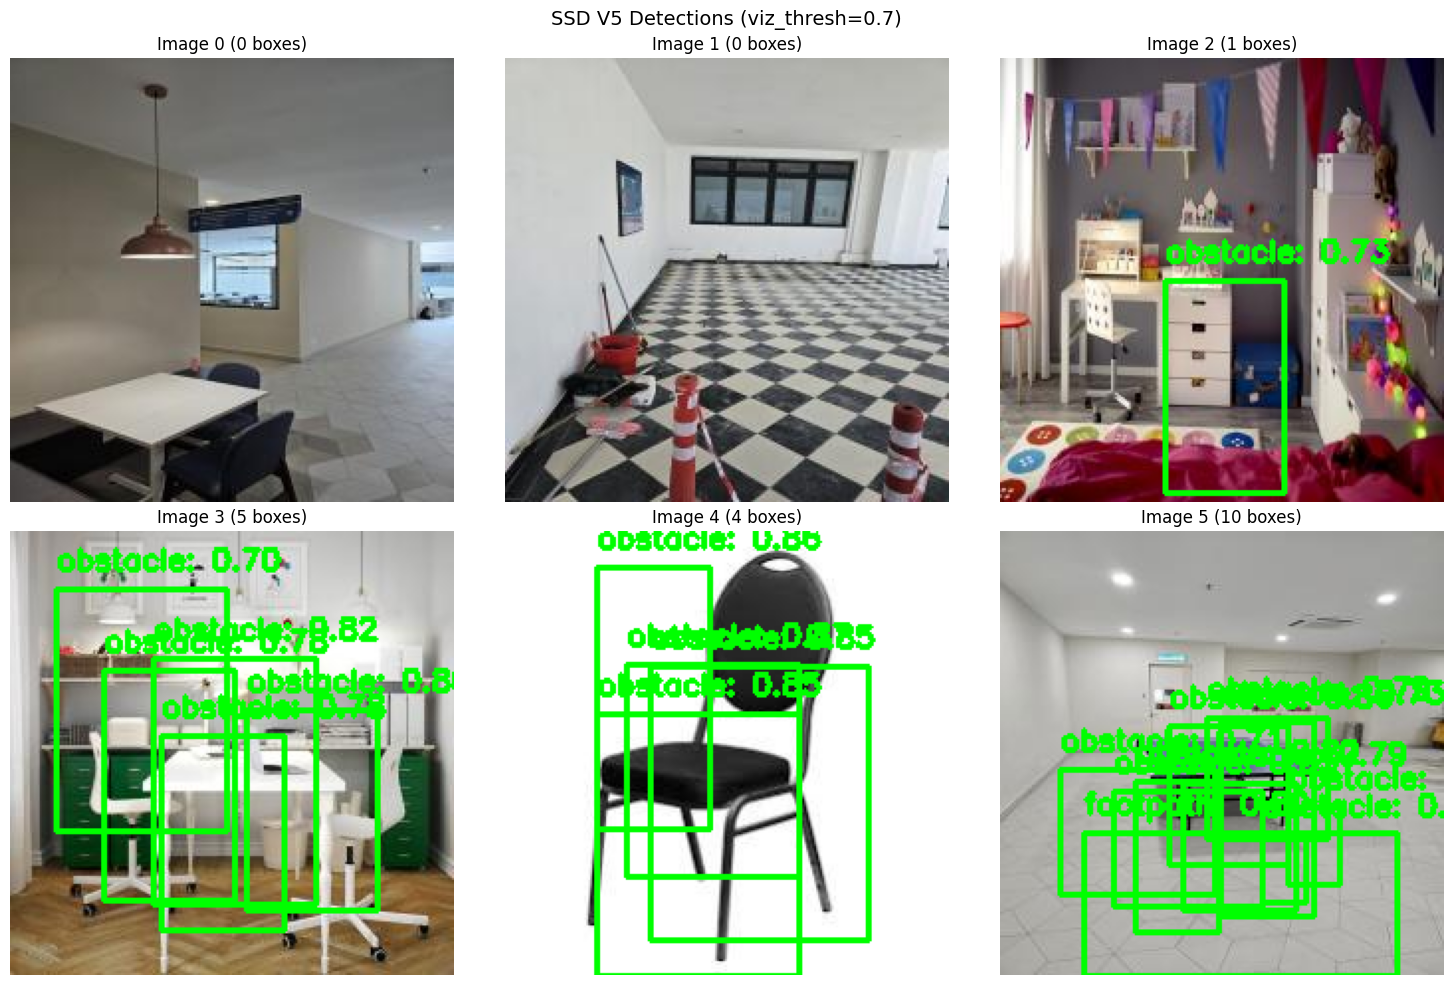

In [27]:
# ============================================================================
# SSD V5 - Visualización de detecciones
# ============================================================================
import matplotlib.pyplot as plt

# Usar un umbral mucho más alto para visualización limpia (modelo tiene overfitting)
VIZ_THRESHOLD = 0.70  # Umbral alto para filtrar falsos positivos
print(f"📊 Umbral para visualización: {VIZ_THRESHOLD}")
print(f"   (Umbral óptimo calculado: {OPTIMAL_OBJ_THRESH_V5})")

# Diagnóstico: distribución de confianzas
all_confs = []
for preds in preds_ssd_v5.values():
    for p in preds:
        all_confs.append(p["confidence"])
if all_confs:
    import numpy as np
    all_confs = np.array(all_confs)
    print(f"\n📈 Distribución de confianzas ({len(all_confs)} predicciones totales):")
    print(f"   Min: {all_confs.min():.3f}, Max: {all_confs.max():.3f}, Media: {all_confs.mean():.3f}")
    print(f"   >0.50: {(all_confs > 0.50).sum()}, >0.70: {(all_confs > 0.70).sum()}, >0.90: {(all_confs > 0.90).sum()}")

sample_image_ids_v5 = list(preds_ssd_v5.keys())[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_id in enumerate(sample_image_ids_v5):
    img_info = next((img for img in test_coco_v5["images"] if img["id"] == img_id), None)
    if img_info is None:
        continue
    img_path = os.path.join(test_images_dir_v5, img_info["file_name"])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Filtrar predicciones por umbral de visualización
    box_count = 0
    for pred in preds_ssd_v5.get(img_id, []):
        if pred["confidence"] < VIZ_THRESHOLD:
            continue  # Saltar predicciones con baja confianza
        x1, y1, x2, y2 = [int(c) for c in pred["bbox_xyxy"]]
        cls_name = pred["class_name"]
        conf = pred["confidence"]
        color = (0, 255, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{cls_name}: {conf:.2f}"
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        box_count += 1
    
    axes[idx].imshow(img)
    axes[idx].set_title(f"Image {img_id} ({box_count} boxes)")
    axes[idx].axis("off")

plt.suptitle(f"SSD V5 Detections (viz_thresh={VIZ_THRESHOLD})", fontsize=14)
plt.tight_layout()
fig_path = os.path.join(config.dirs["visuals"], "ssd_anchor_v5_detections.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"\n✅ Visualización guardada en: {fig_path}")
plt.show()

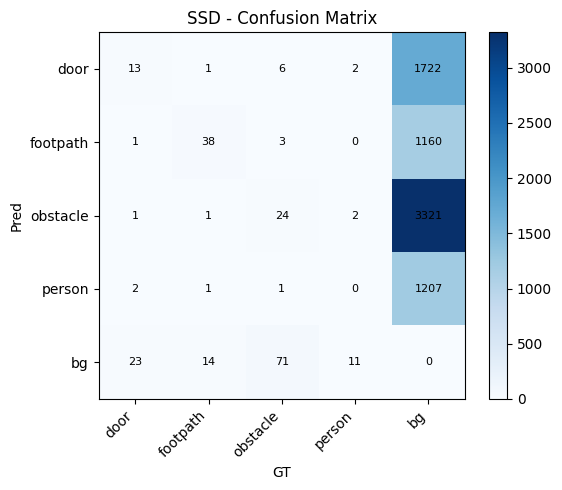

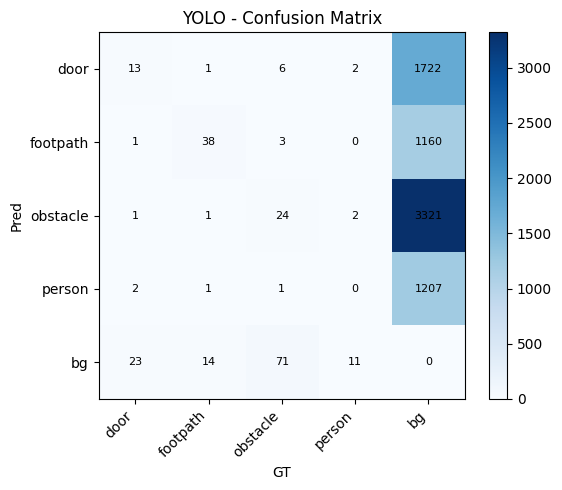

In [28]:
# Matrices de confusión
from utils_compare import plot_confusion_matrices

plot_confusion_matrices(metrics_ssd_v5, metrics_ssd_v5, CLASS_NAMES)